# XY Graphs

Outputs to folder `dauer_paper/figures`.

Plot values are based on pre-calculated fixed values stored in:
`analysis_modules/dataset_stats/outputs/dataset_summary_statistics.csv`



Saved figure to figures/dataset_stats\connections_plot.png and figures/dataset_stats\connections_plot.pdf
Saved figure to figures/dataset_stats\contacts_plot.png and figures/dataset_stats\contacts_plot.pdf
Saved figure to figures/dataset_stats\synapses_plot.png and figures/dataset_stats\synapses_plot.pdf
Saved figure to figures/dataset_stats\cable_length_plot.png and figures/dataset_stats\cable_length_plot.pdf
Saved figure to figures/dataset_stats\volume_plot.png and figures/dataset_stats\volume_plot.pdf
Saved figure to figures/dataset_stats\contact_surface_plot.png and figures/dataset_stats\contact_surface_plot.pdf


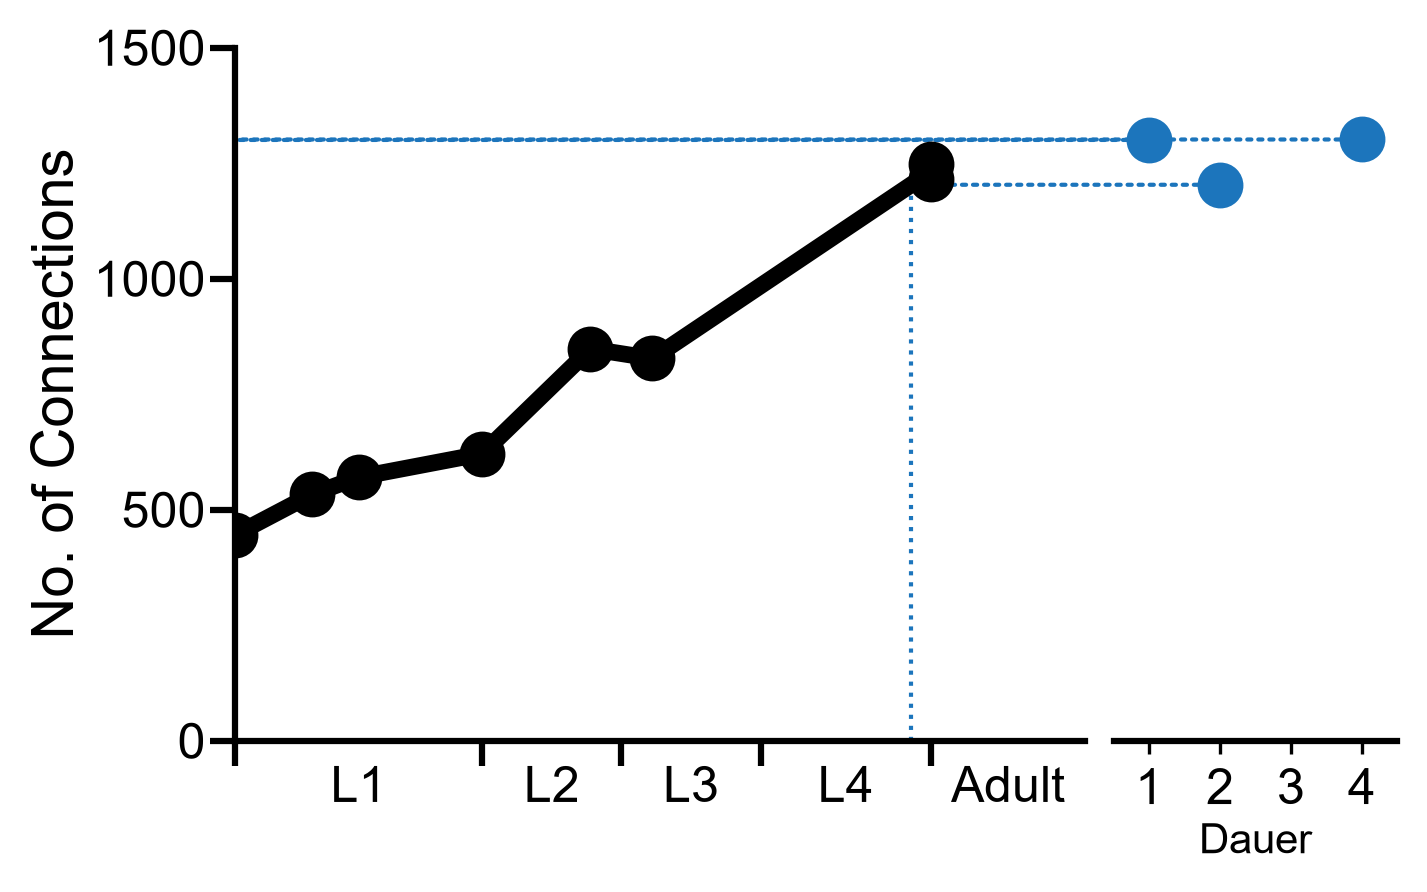

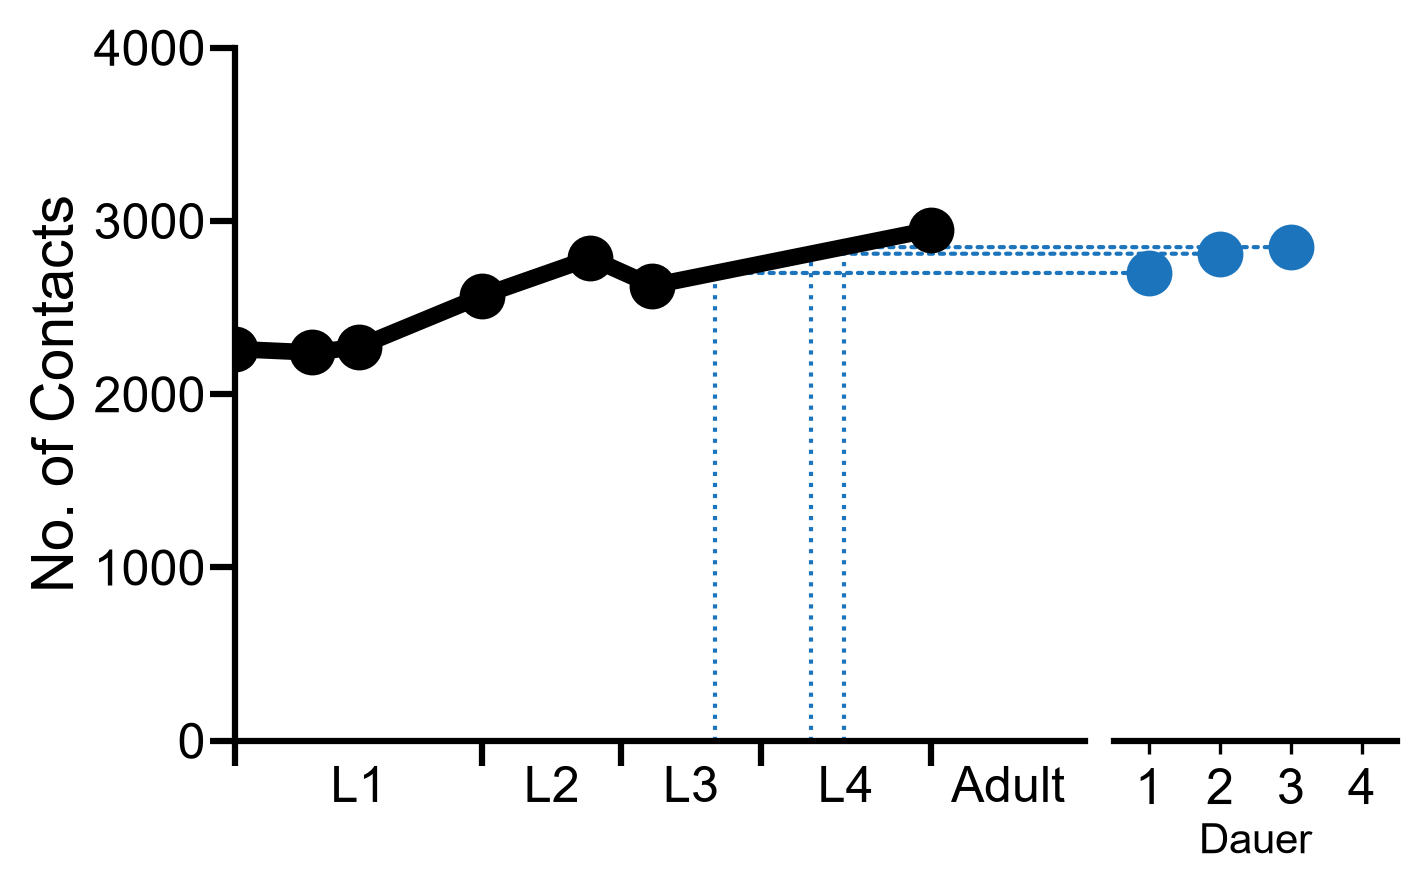

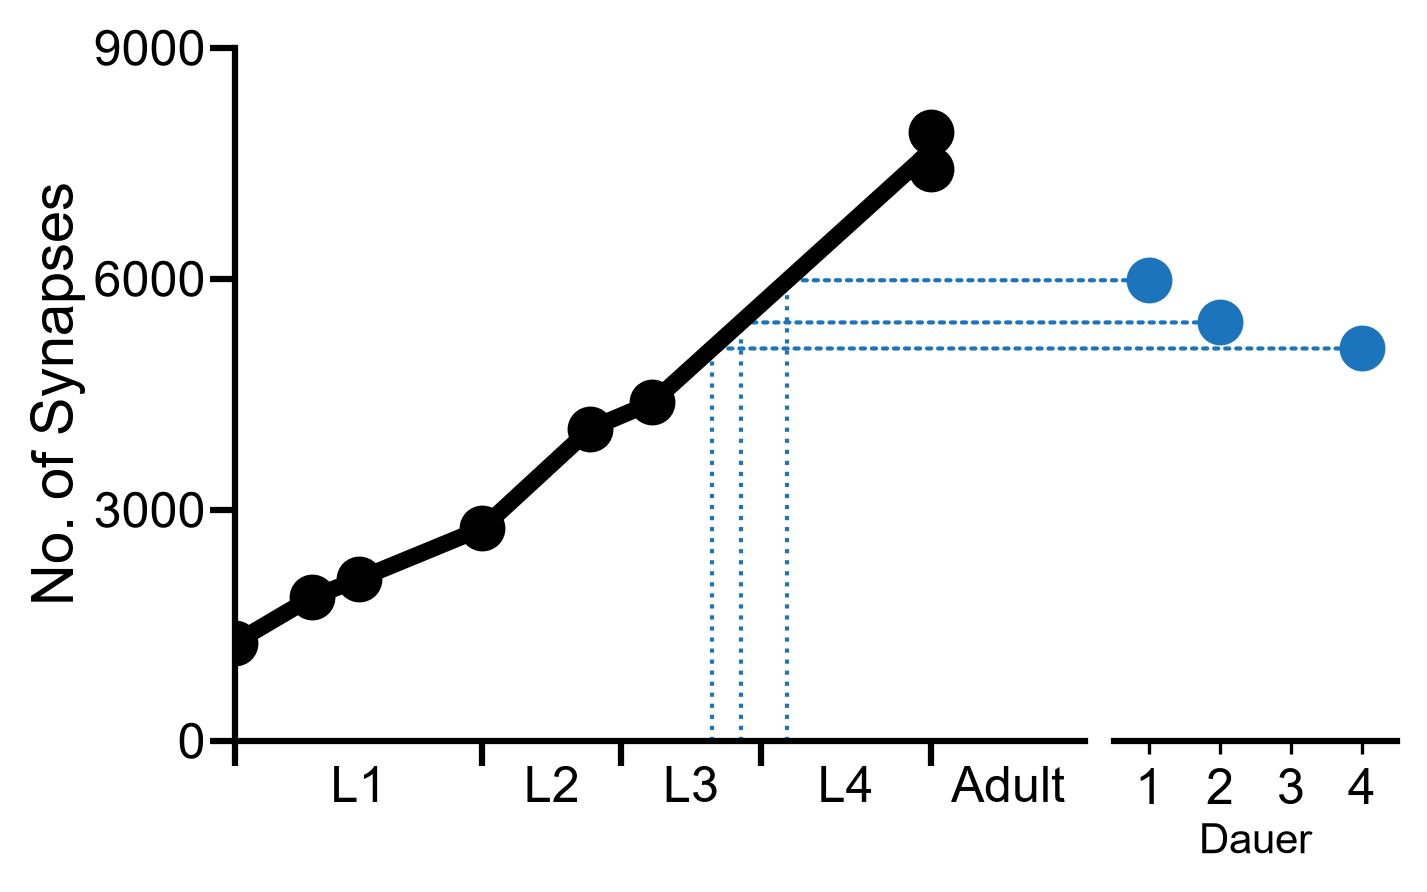

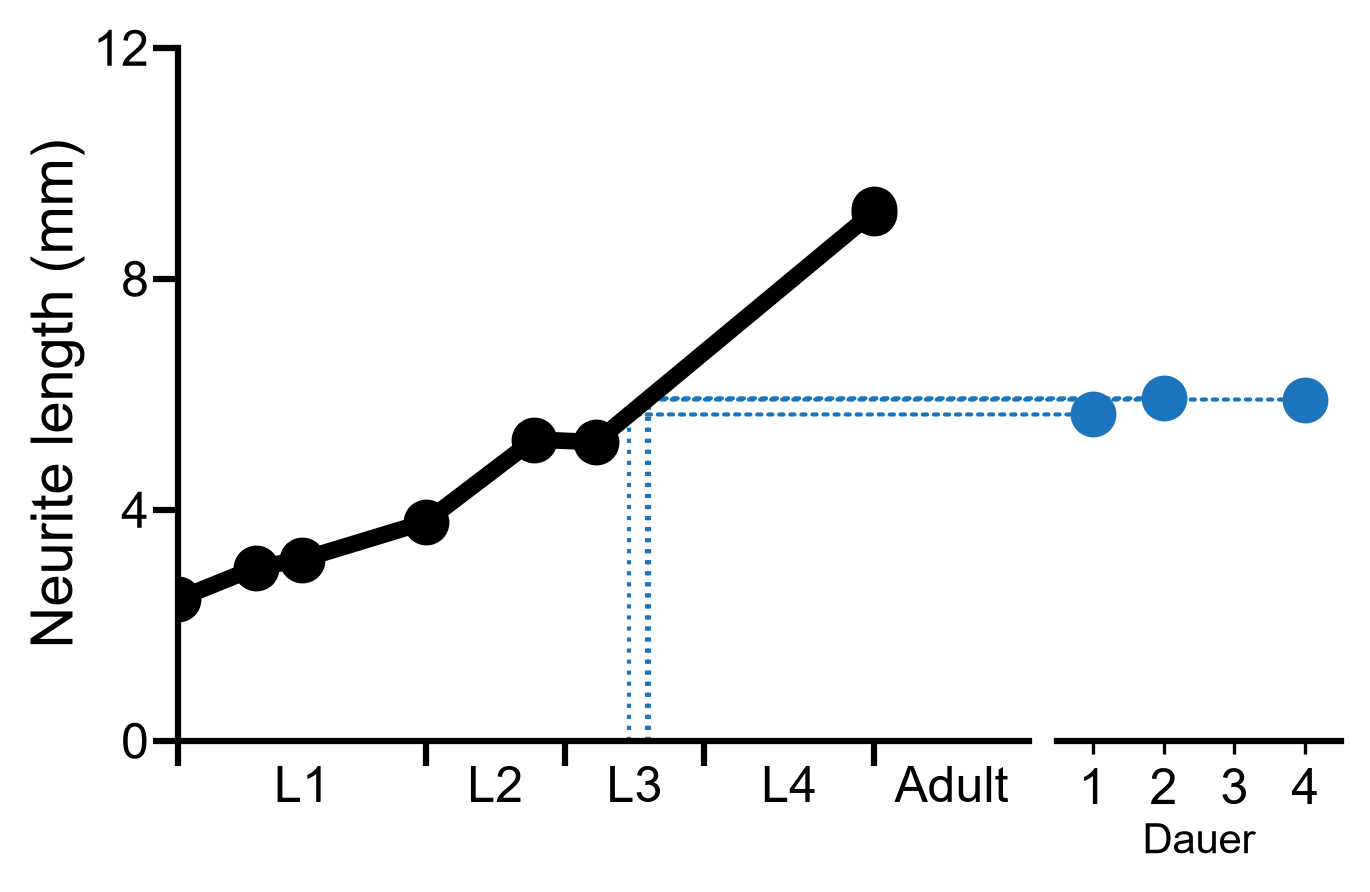

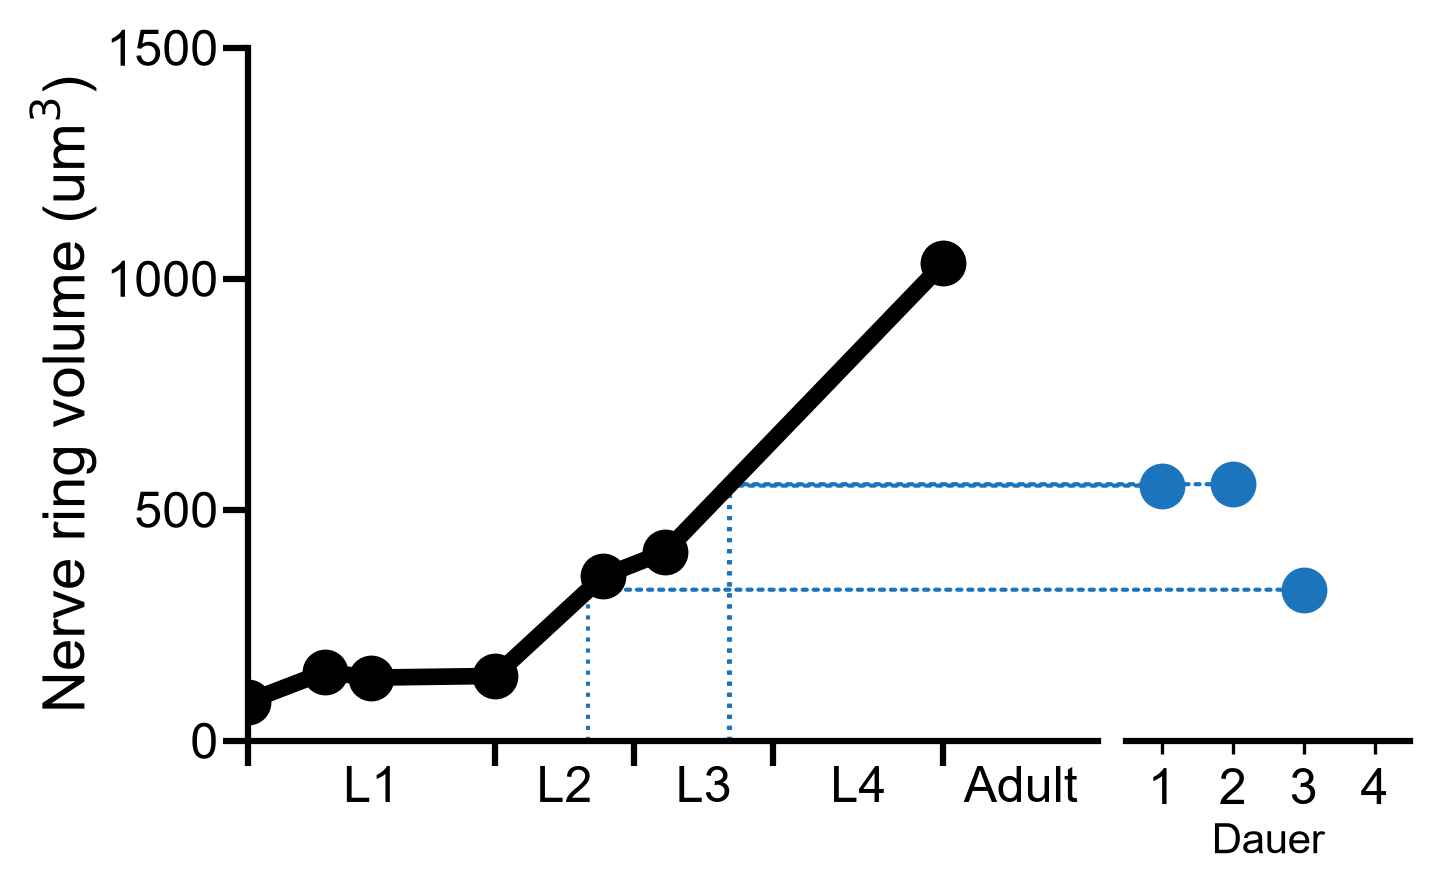

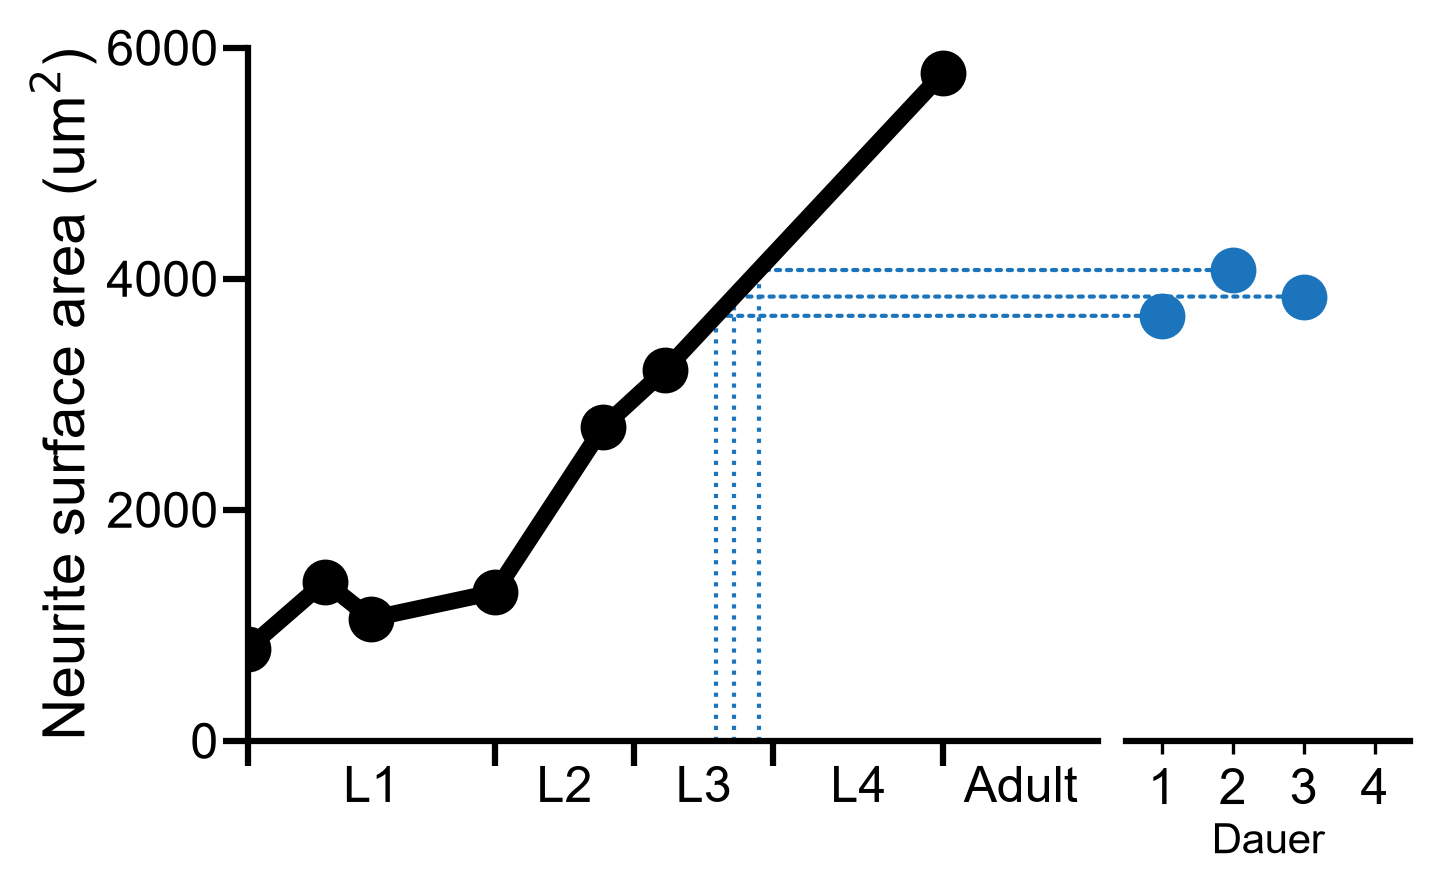

In [2]:
import pandas as pd
import numpy as np
import json
from plotting.plotter import Plotter

file_path = 'analysis_modules/dataset_stats/outputs/dataset_summary_statistics.csv'
parameter_path = 'plotting/utils/xy_graph_parameters.csv'
metadata_path = 'plotting/utils/metadata.json'

# Load and process the data
data = pd.read_csv(file_path, index_col=0)
params = pd.read_csv(parameter_path)
with open(metadata_path, 'r') as f:
    metadata = json.load(f)

data['type'] = data.index.map(lambda x: 'dauer' if metadata[x]['stage']=='dauer' else 'nondauer')
data['timepoint'] = data.index.map(lambda x: metadata[x]['age_visual'])

for plot_metric in params['variable_name'].values:
    filt = params['variable_name']==plot_metric
    ymin = params[filt]['y_axis_min'].values[0]
    ymax = params[filt]['y_axis_max'].values[0]
    ylabel = params[filt]['ylabel'].values[0]
    yticks = np.linspace(ymin, ymax, params[filt]['n_yticks'].values[0])

    if plot_metric == 'cable_length':
        data[plot_metric] = (data[plot_metric])/1000000
    if plot_metric == 'contact_surface':
        data[plot_metric] = (data[plot_metric])/1000000
        ylabel = f'{ylabel} (um$^2$)'
    if plot_metric == 'volume':
        data[plot_metric] = (data[plot_metric])/1000000000
        ylabel = f'{ylabel} (um$^3$)'

    # Filter for nondauer data
    filt_nondauer = (data['type'] == 'nondauer') & ~np.isnan(data[plot_metric])
    x_nondauer = data[filt_nondauer]['timepoint'].values
    y_nondauer = data[filt_nondauer][plot_metric].values

    # Filter for dauer data
    filt_dauer = (data['type'] == 'dauer') & ~np.isnan(data[plot_metric])
    x_dauer = data[filt_dauer]['timepoint'].values
    y_dauer = data[filt_dauer][plot_metric].values

    # Plotting
    figure_generator = Plotter(output_path='figures/dataset_stats')
    figure_generator.plot_xy_graph(
        x=x_nondauer,
        y=y_nondauer,
        x_dauer=x_dauer,
        y_dauer=y_dauer,
        ymin=ymin,
        ymax=ymax,
        ylabel=ylabel,
        yticks=yticks,
        save_as = f'{plot_metric}_plot',
        connect_points=True,
        dauer_lines=True
    )

# Cytoscape-like Graph

Define dataset and data type in first cell, outputs to `dauer_paper/figures`

In [3]:
from pathlib import Path

# parameters
dataset = 'L1-3'
data_type = 'connectome' # 'connectome', 'proximity'

output_name = Path(f'cytoscape_graph_{dataset}.png')

Created directory: figures\graphs


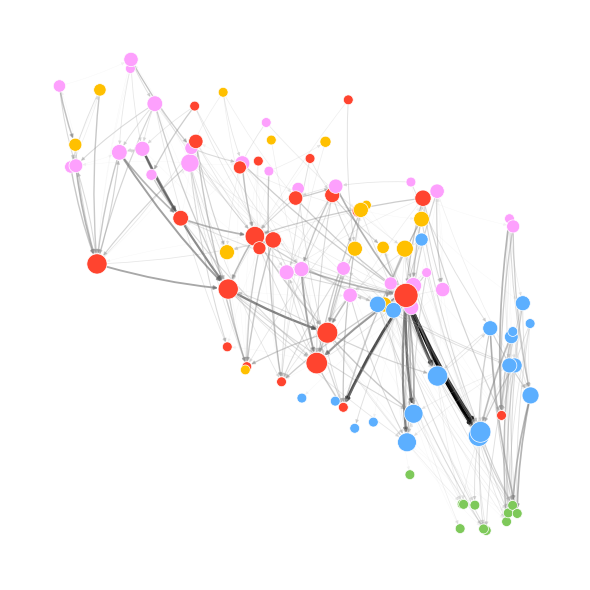

In [5]:
from pathlib import Path
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from analysis_modules.src.neuron_info import ntype, dark_colors
from analysis_modules.src.data_manager import DataManager
import pandas as pd


node_info_path = 'plotting/utils/node_coordinates.csv'
node_info = pd.read_csv(node_info_path)
node_info.index = node_info['name']

dm = DataManager(
    data_path = 'data',
    include_muscle = True,
    include_postemb = True,
    npair_result = True
)
data = dm.get_data_edgetable(data_type)
plot_data = data[dataset].rename('weight')

# data params
ignore_neurons = ['PVW','PLN','HSN']
minimum_edge_weight = 2
ignore_self_edges = True

# plotting params
n_size_min,n_size_max = 50,300.0
e_width_min,e_width_max = 0.25,2.5
e_color_min,e_color_max = 0.8,0.0

# ignore neurons
plot_data = plot_data[~plot_data.index.get_level_values(0).isin(ignore_neurons)]
plot_data = plot_data[~plot_data.index.get_level_values(1).isin(ignore_neurons)]

# ignore self edge loop
if ignore_self_edges:
    plot_data = plot_data[~(plot_data.index.get_level_values(0) == plot_data.index.get_level_values(1))]

# set edge weight minimum
plot_data = plot_data[plot_data >= minimum_edge_weight]

outputs = plot_data.astype(bool).groupby(level=0).sum()
inputs = plot_data.astype(bool).groupby(level=1).sum()
node_degree = (outputs+inputs).fillna(0)

G = nx.DiGraph()
pos = {
    key: (value['x']*0.8, -value['z'])
    for key, value in node_info[['x','z']].T.to_dict().items()
}

# formulas for variable node size / edge width / edge color
n_min, n_max = node_degree.min(), node_degree.max()
e_min, e_max = plot_data.min(), plot_data.max()

def _norm(w, lo, hi, gamma=1.0):
    return float(np.clip((w - lo) / (hi - lo), 0.0, 1.0)) ** gamma

def node_size_formula(w):
    t = _norm(w, n_min, n_max, gamma=1)
    r0, r1 = np.sqrt(n_size_min), np.sqrt(n_size_max)
    return (r0 + t * (r1 - r0)) ** 2

def edge_size_formula(w):
    t = _norm(w, e_min, e_max, gamma=0.7)
    return e_width_min + t * (e_width_max - e_width_min)

def edge_color_formula(w):
    t = _norm(w, e_min, e_max, gamma=0.7)
    g = e_color_min + t * (e_color_max - e_color_min)
    return (g, g, g, 1-g)

nodelist = list(node_degree.index)
node_sizes = np.array([node_size_formula(w) for w in node_degree[nodelist]])
node_colors = [dark_colors[ntype(n)] for n in nodelist]

# plotting
fig, ax = plt.subplots(figsize=(6, 6))
nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=nodelist,
    node_color=node_colors,
    node_size=node_sizes,
    edgecolors = 'White',
    linewidths = 0.5
).set_zorder(2)

nx.draw_networkx_edges(
    G,
    pos,
    nodelist=nodelist,
    node_size=node_sizes,
    edgelist = plot_data.index,
    width=[edge_size_formula(w) for w in plot_data],
    edge_color=[edge_color_formula(w) for w in plot_data],
    arrows=True,
    arrowsize=5,
    arrowstyle="-|>",
    connectionstyle="arc3,rad=0.05",
)

plt.axis('off')
plt.tight_layout()

output_path = Path('figures/graphs/')
if not output_path.exists():
    output_path.mkdir(parents=True, exist_ok=True)
    print(f"Created directory: {output_path}")
plt.savefig(output_path / output_name, dpi=300, bbox_inches='tight')

Calculate the top 5% and bottom 5% synapse drive, and plot their edges

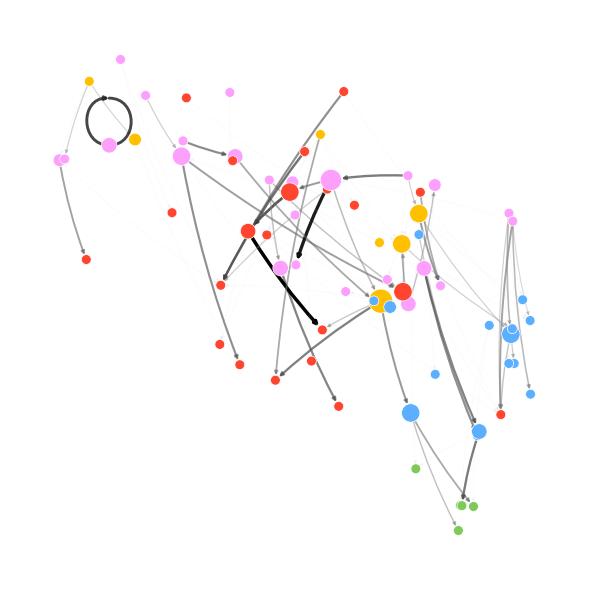

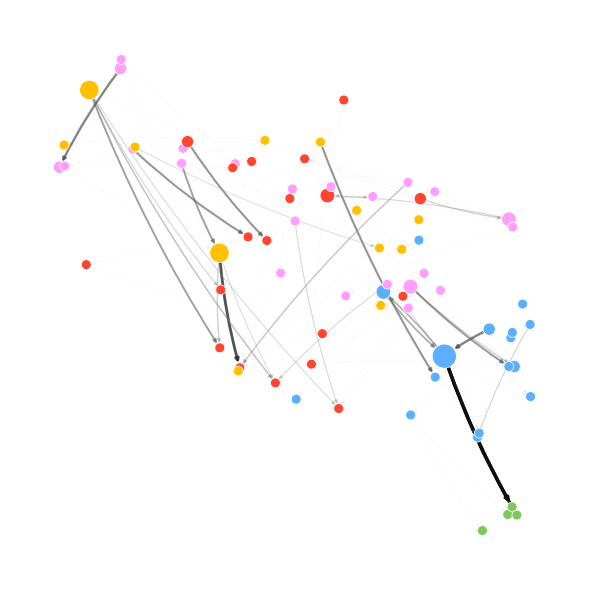

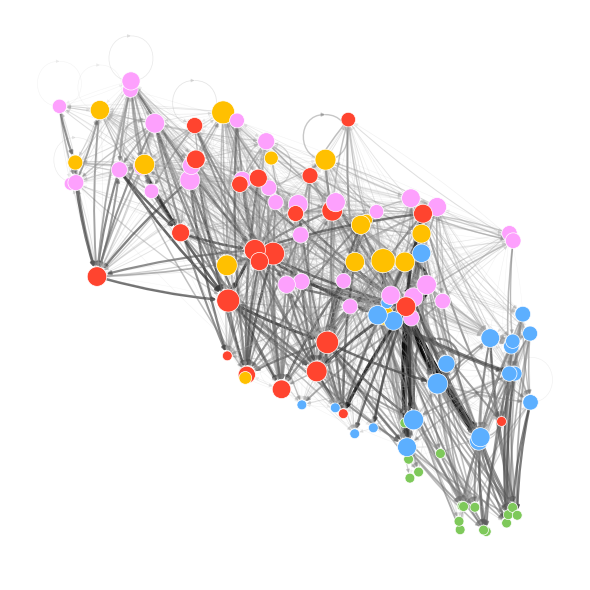

In [6]:
from pathlib import Path
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from analysis_modules.src.neuron_info import ntype, dark_colors
from analysis_modules.src.data_manager import DataManager

dm = DataManager(
    data_path = 'data',
    include_muscle = True,
    include_postemb = True,
    npair_result = True
)

drive_values = dm.get_drive_edgetable(consistent=True)
drive_values['nondauer_mean'] = drive_values.loc[:,['L2','L3','adult-2']].mean(axis=1)
drive_values['dauer_mean'] = drive_values.loc[:,['dauer-1','dauer-2']].mean(axis=1)
drive_values['mean'] = drive_values.loc[:,['L2','L3','adult-2','dauer-1','dauer-2']].mean(axis=1)
drive_loadings = pd.read_csv('analysis_modules/pca/outputs/drive_loadings.csv', index_col=[0,1])

plot_data = {
    'top': {
        'data': drive_values.loc[drive_loadings.iloc[:90].index]['dauer_mean'],
        'output_name': 'top_drive_graph.png'
    },
    'bottom': {
        'data': drive_values.loc[drive_loadings.iloc[-90:].index]['nondauer_mean'],
        'output_name': 'bottom_drive_graph.png'
    },
    'middle': {
        'data': drive_values.loc[drive_loadings.iloc[90:-90].index]['mean'],
        'output_name': 'middle_drive_graph.png'
    }
}

node_info_path = 'plotting/utils/node_coordinates.csv'
node_info = pd.read_csv(node_info_path)
node_info.index = node_info['name']

# plotting params
n_size_min,n_size_max = 50,300.0
e_width_min,e_width_max = 0.25,2.5
e_color_min,e_color_max = 0.8,0.0

for k,v in plot_data.items():
    plot_data = v['data']
    output_name = v['output_name']

    outputs = plot_data.astype(bool).groupby(level=0).sum()
    inputs = plot_data.astype(bool).groupby(level=1).sum()
    node_degree = (outputs+inputs).fillna(0)

    G = nx.DiGraph()
    pos = {
        key: (value['x']*0.8, -value['z'])
        for key, value in node_info[['x','z']].T.to_dict().items()
    }

    # formulas for variable node size / edge width / edge color
    n_min, n_max = node_degree.min(), node_degree.max()
    e_min, e_max = plot_data.min(), plot_data.max()

    def _norm(w, lo, hi, gamma=1.0):
        return float(np.clip((w - lo) / (hi - lo), 0.0, 1.0)) ** gamma

    def node_size_formula(w):
        t = _norm(w, n_min, n_max, gamma=1)
        r0, r1 = np.sqrt(n_size_min), np.sqrt(n_size_max)
        return (r0 + t * (r1 - r0)) ** 2

    def edge_size_formula(w):
        t = _norm(w, e_min, e_max, gamma=0.7)
        return e_width_min + t * (e_width_max - e_width_min)

    def edge_color_formula(w):
        t = _norm(w, e_min, e_max, gamma=0.7)
        g = e_color_min + t * (e_color_max - e_color_min)
        return (g, g, g, 1-g)

    nodelist = list(node_degree.index)
    node_sizes = np.array([node_size_formula(w) for w in node_degree.loc[nodelist]])
    node_colors = [dark_colors[ntype(n)] for n in nodelist]

    # plotting
    fig, ax = plt.subplots(figsize=(6, 6))
    nx.draw_networkx_nodes(
        G,
        pos,
        nodelist=nodelist,
        node_color=node_colors,
        node_size=node_sizes,
        edgecolors = 'White',
        linewidths = 0.5
    ).set_zorder(2)

    nx.draw_networkx_edges(
        G,
        pos,
        nodelist=nodelist,
        node_size=node_sizes,
        edgelist = plot_data.index,
        width=[edge_size_formula(w) for w in plot_data],
        edge_color=[edge_color_formula(w) for w in plot_data],
        arrows=True,
        arrowsize=5,
        arrowstyle="-|>",
        connectionstyle="arc3,rad=0.05",
    )

    plt.axis('off')
    plt.tight_layout()

    output_path = Path('figures/graphs/')
    if not output_path.exists():
        output_path.mkdir(parents=True, exist_ok=True)
        print(f"Created directory: {output_path}")
    plt.savefig(output_path / output_name, dpi=300, bbox_inches='tight')

# Ridgeplot (distribution) and simple scatter (connections/neuron)

Outputs to `figures/ridgeplots`

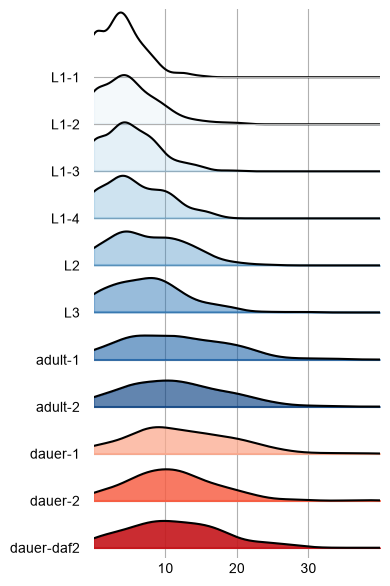

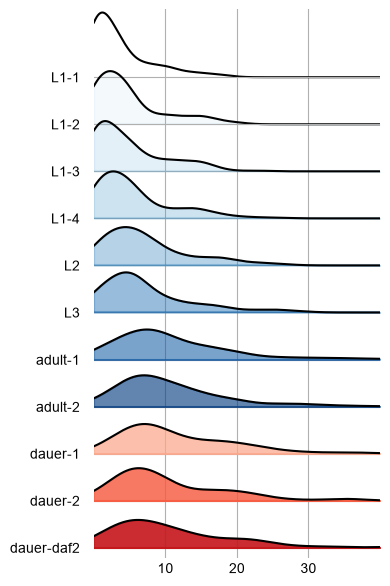

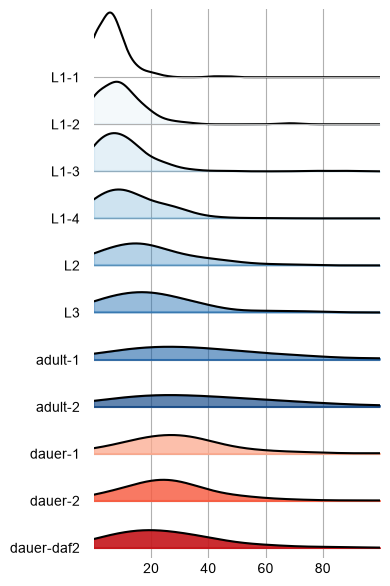

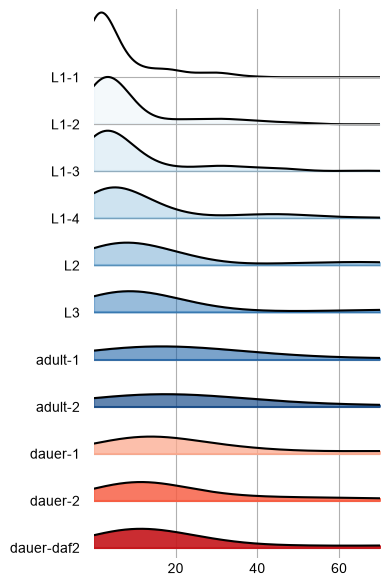

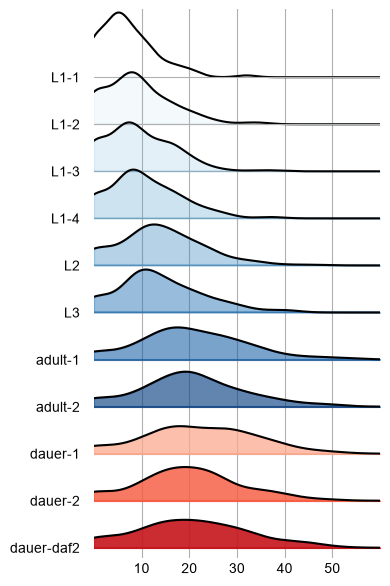

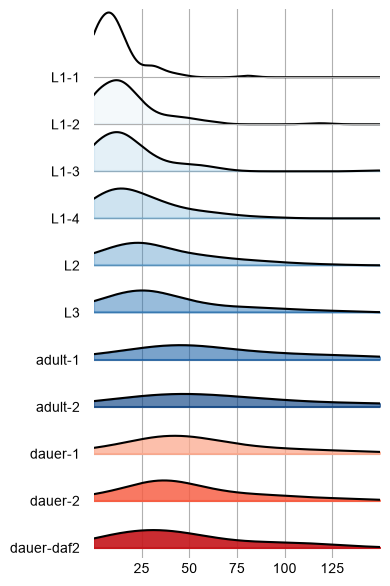

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from joypy import joyplot
from matplotlib.colors import LinearSegmentedColormap
from analysis_modules.src.data_manager import DataManager
from pathlib import Path
import logging
logging.getLogger('matplotlib').setLevel(logging.ERROR)

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'sans-serif']
plt.rc('xtick', labelsize=12)
plt.rc('ytick', labelsize=12)
plt.rc('axes', labelsize=12)

dm = DataManager(
    data_path = 'data',
    include_postemb=True,
    include_muscle=False, # neurons only, muscle input counts excluded
    npair_result=False
)

con_el = dm.get_data_edgetable('connectome')
outputs_syn = con_el.groupby(level=0).sum()
inputs_syn = con_el.groupby(level=1).sum()
outputs_con = con_el.astype(bool).groupby(level=0).sum()
inputs_con = con_el.astype(bool).groupby(level=1).sum()
all_syn = (outputs_syn+inputs_syn).fillna(0)
all_con = (outputs_con+inputs_con).fillna(0)

plotting_params = {
    'connection_out': {
        'data': outputs_con,
        'x_range': [0,40]
    },
    'connection_in': {
        'data': inputs_con,
        'x_range': [0,40]
    },
    'synapse_out': {
        'data': outputs_syn,
        'x_range': [0,100]
    },
    'synapse_in': {
        'data': inputs_syn,
        'x_range': [0,70]
    },
    'connection_all': {
        'data': all_con,
        'x_range': [0,60]
    },
    'synapse_all': {
        'data': all_syn,
        'x_range': [0,150]
    },
}

colors1 = plt.get_cmap('Blues')(np.linspace(0.33, 1, 70))
colors2 = plt.get_cmap('Reds')(np.linspace(0.25, 1, 30))

colors = np.vstack((colors1, colors2))
colors[:,-1] = np.linspace(0, 1, 100)
cmap = LinearSegmentedColormap.from_list('white_blue_white_red', colors)

output_path = Path('figures/ridgeplots')
if not output_path.exists():
    output_path.mkdir(parents=True, exist_ok=True)
    print(f"Created directory: {output_path}")

for k,v in plotting_params.items():
    data = v['data']
    x_range = v['x_range']

    fig = joyplot(
        data=data,
        colormap=cmap,
        labels=con_el.columns,
        range_style='all',
        tails=0.1,
        overlap=0.5,
        grid=True,
        x_range = x_range,
        figsize=(4,6)
    )
    plt.savefig(output_path / Path(k+'.png'), dpi=300, bbox_inches='tight')
    plt.show()

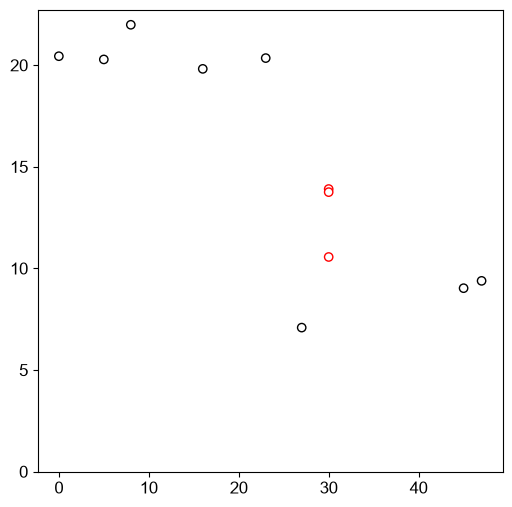

In [6]:
# Simple scatter: figure 2i and 2j were based off this plot

data_type = 'connection_all'

x = [0,5,8,16,23,27,45,47,30,30,30]
edge_colors = ['black','black','black','black','black','black',
          'black','black','red','red','red']

output_path = Path('figures/simple_scatter')
if not output_path.exists():
    output_path.mkdir()
    print(f"Created directory: {output_path}")

plt.figure(figsize=(6,6))
plt.scatter(x,plotting_params[data_type]['data'].mean(), color = 'white', edgecolors = edge_colors)
plt.ylim(bottom=0)
plt.savefig(output_path / Path(f'mean_{data_type}_plot.png'),dpi=300,bbox_inches='tight')
plt.show()

# Wasserstein plot

Outputs to `figures/wasserstein`

Created directory: figures\wasserstein


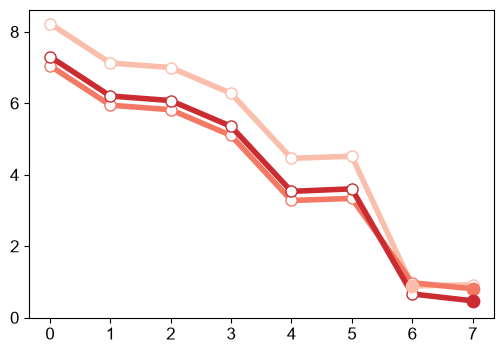

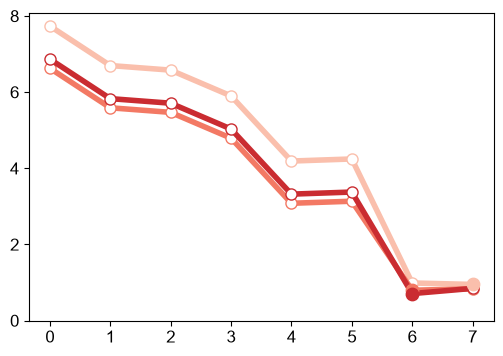

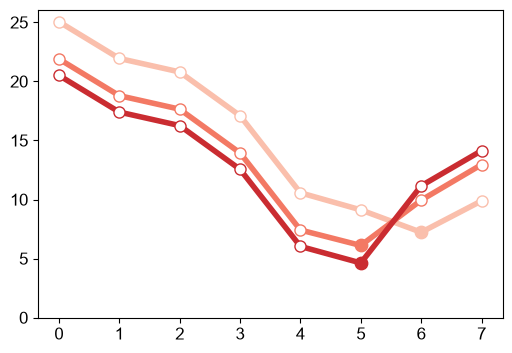

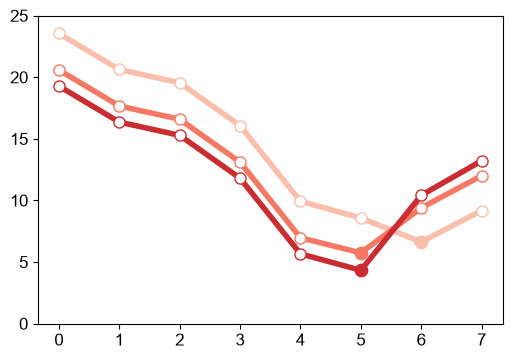

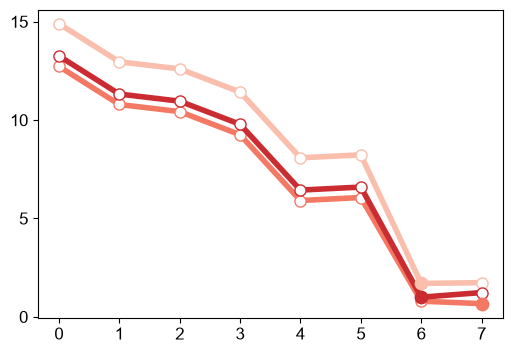

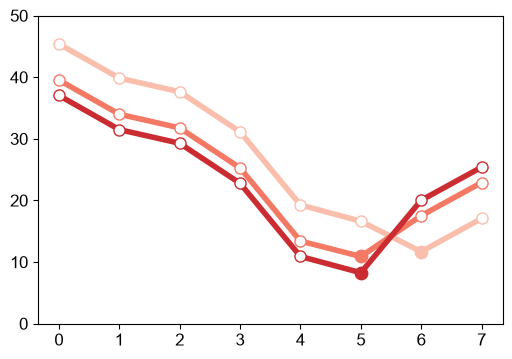

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import wasserstein_distance
from analysis_modules.src.data_manager import DataManager

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'sans-serif']
plt.rc('xtick', labelsize=12)
plt.rc('ytick', labelsize=12)
plt.rc('axes', labelsize=12)

dm = DataManager(
    data_path = 'data',
    include_postemb=True,
    include_muscle=False,
    npair_result=False
)

con_el = dm.get_data_edgetable('connectome')
outputs_syn = con_el.groupby(level=0).sum()
inputs_syn = con_el.groupby(level=1).sum()
outputs_con = con_el.astype(bool).groupby(level=0).sum()
inputs_con = con_el.astype(bool).groupby(level=1).sum()
all_syn = (outputs_syn+inputs_syn).fillna(0)
all_con = (outputs_con+inputs_con).fillna(0)

plotting_params = {
    'connection_out': {
        'data': outputs_con,
        'yticks': np.arange(0,10,2)
    },
    'connection_in': {
        'data': inputs_con,
        'yticks': np.arange(0,10,2)
    },
    'synapse_out': {
        'data': outputs_syn,
        'yticks': np.arange(0,30,5)
    },
    'synapse_in': {
        'data': inputs_syn,
        'yticks': np.arange(0,30,5)
    },
    'connection_all': {
        'data': all_con,
        'yticks': np.arange(0,20,5)
    },
    'synapse_all': {
        'data': all_syn,
        'yticks': np.arange(0,60,10)
    },
}

datasets = ['dauer-1','dauer-2','dauer-daf2']

output_path = Path('figures/wasserstein')
if not output_path.exists():
    output_path.mkdir(parents=True, exist_ok=True)
    print(f"Created directory: {output_path}")

for k,v in plotting_params.items():
    data = v['data']
    yticks = v['yticks']

    distances = {}
    for dataset in datasets:
        reference_data = np.array(data.iloc[:,:-3])
        new_dataset = np.array(data.loc[:,dataset])
        distances[dataset] = []
        num_datasets = reference_data.shape[1]

        for i in range(num_datasets):
            ref_dataset = reference_data[:, i]
            dist = wasserstein_distance(new_dataset, ref_dataset)
            distances[dataset].append(dist)

    # Plotting
    fig, ax = plt.subplots(figsize=(6, 4))
    x = np.arange(num_datasets)

    line_colors = {
        'dauer-1': '#fabfac',
        'dauer-2': '#f37964',
        'dauer-daf2': '#ca2c31'
    }

    for dataset in datasets:
        inferred_age = np.argmin(distances[dataset])

        ax.plot(
            x, distances[dataset], marker='o', linestyle='-', markerfacecolor='white',
            markersize=8, color=line_colors[dataset], linewidth=4, label=f'{dataset}')
        ax.scatter(
            x[inferred_age], distances[dataset][inferred_age],
            s=80, zorder=5, color=line_colors[dataset])
    plt.yticks(yticks)
    plt.savefig(output_path / Path(k+'_wasserstein.png'), dpi=300, bbox_inches='tight')

# PCA

The first cell outputs a .json containing the PCA data. The second cell plots the PCA from the .json. JSON located in `/analysis_modules/pca/outputs/` and PCA plots in `figures/pca`

In [27]:
from pathlib import Path
import json
import numpy as np
from analysis_modules.pca.pca import run_pca
from analysis_modules.src.utils import exclude_postemb_edgetable
from analysis_modules.src.data_manager import DataManager

# datatype = 'connectome'
pca_root = Path('analysis_modules/pca/outputs')
pca_components = 2

dataset_selection = {
    'connectome_all': [
        'L1-1','L1-2','L1-3','L1-4',
        'L2','L3','adult-1','adult-2',
        'dauer-1','dauer-2','dauer-daf2'
    ],
    'connectome': [
        'L2','L3','adult-1','adult-2',
        'dauer-1','dauer-2','dauer-daf2'
    ],
    'proximity': [
        'L2','L3','adult-2',
        'dauer-1','dauer-2','dauer-3'
    ],
    'drive': [
        'L2','L3','adult-2','dauer-1','dauer-2'
    ],
    'connectome_2_dauer': [
        'L2','L3','adult-1','adult-2',
        'dauer-1','dauer-2'
    ],
    'proximity_2_dauer': [
        'L2','L3','adult-2',
        'dauer-1','dauer-2'
    ],
}

for datatype in dataset_selection.keys():
    # include datasets
    ds = dataset_selection[datatype]

    dm = DataManager(
        data_path='data',
        include_postemb=True,
        include_muscle=True,
        npair_result=True
    )

    if datatype == 'drive':
        edgetable = dm.get_drive_edgetable(consistent=True)
    elif datatype in ['connectome_all', 'connectome_2_dauer']:
        edgetable = dm.get_data_edgetable('connectome')
    elif datatype == 'proximity_2_dauer':
        edgetable = dm.get_data_edgetable('proximity')
    else:
        edgetable = dm.get_data_edgetable(datatype)
    edgetable = edgetable.loc[:,ds]

    if datatype == 'connectome':
        edgetable = np.sqrt(edgetable)
    if datatype == 'proximity':
        edgetable[edgetable<10]=0
        edgetable = edgetable.replace(0,np.nan)
        edgetable = np.log(edgetable)

    # exclude postembryonic neurons from index
    edgetable = exclude_postemb_edgetable(edgetable, ds)

    edgetable = edgetable.fillna(0)
    edgetable = edgetable[edgetable.sum(axis=1) > 0]

    output_data = run_pca(edgetable, pca_components)

    output_file = Path(f'pca_{datatype}.json')
    with open(pca_root / output_file, 'w+') as fp:
        json.dump(output_data, fp, indent=4)

Saved figure to figures/pca\pca_connectome_all.png.png and figures/pca\pca_connectome_all.png.pdf
Saved figure to figures/pca\pca_connectome.png.png and figures/pca\pca_connectome.png.pdf
Saved figure to figures/pca\pca_proximity.png.png and figures/pca\pca_proximity.png.pdf
Saved figure to figures/pca\pca_drive.png.png and figures/pca\pca_drive.png.pdf


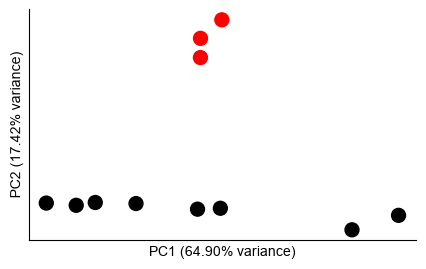

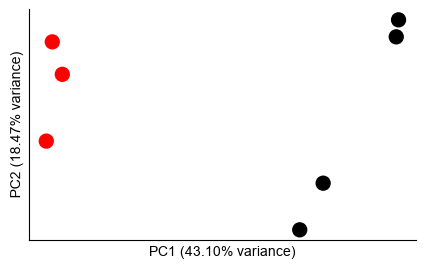

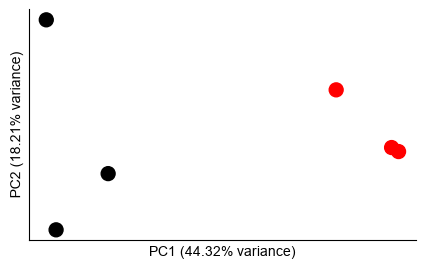

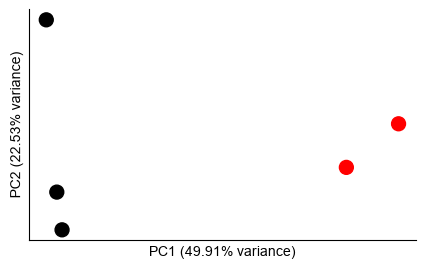

In [4]:
import numpy as np
import json
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from plotting.plotter import Plotter

output_path = Path('figures/pca')
if not output_path.exists():
    output_path.mkdir(parents=True, exist_ok=True)
    print(f"Created directory: {output_path}")

for datatype in dataset_selection.keys():
    input_file = Path(f'pca_{datatype}.json')
    input_path = pca_root / input_file
    use_kmeans_labels=True

    with open(input_path, 'r') as f:
        data = json.load(f)
    data['features'] = np.array(data['features'])
    # labels = data['labels']

    cmap = ListedColormap(['k','#FF0000'])
    s= 100

    xlabel = f'PC1 ({data['explained_variance'][0]:.2%} variance)'
    ylabel = f'PC2 ({data['explained_variance'][1]:.2%} variance)'


    figure_generator = Plotter(output_path='figures/pca')
    figure_generator.plot_pca(
        data['features'][:,0],
        data['features'][:,1],
        xlabel,
        ylabel,
        labels=None,
        clabels=data['cluster_labels'] if use_kmeans_labels else None,
        cmap=cmap,
        save_as=f'pca_{datatype}.png',
    )

# PCA Loading Plot

Outputs PCA loading histogram dot plot to `figures/pca_loading`. Histogram can be colored based on classification (e.g. dauer_increased, dauer_decreased) or with gradient. Synapse drive is plotted with gradient.

Saved figure to figures/pca_loading\connectome_loadings.png and figures/pca_loading\connectome_loadings.pdf


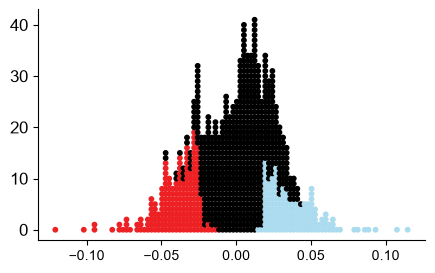

Saved figure to figures/pca_loading\proximity_loadings.png and figures/pca_loading\proximity_loadings.pdf


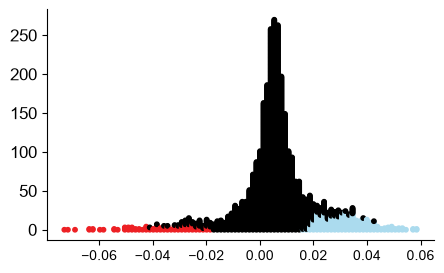

In [11]:
import pandas as pd
from pathlib import Path
from plotting.plotter import Plotter

# datatype = 'connectome'

for datatype in ['connectome','proximity']:
    # plot loadings with colors based on classification (dauer_increased, e.g.)
    loading_path = Path('analysis_modules/pca/outputs')
    loading_file = Path(f'{datatype}_loadings.csv')
    loading_df = pd.read_csv(loading_path / loading_file, index_col=[0,1])

    classification_path = Path('data/connectomes/metadata/synapse_neighborhood_classification_table.csv')
    class_data = pd.read_csv(classification_path, index_col=[0,1])

    plot_classes = {
        'connectome': {
            'classes': ['dauer_increased','dauer_decreased','maintained'],
            'df_column': 'connectivity_3_dauer'
        },
        'proximity':{
            'classes': ['dauer_increased','dauer_decreased','maintained'],
            'df_column': 'neighborhood_3_dauer'
        }
    }

    plot_index = class_data[class_data[plot_classes[datatype]['df_column']].isin(plot_classes[datatype]['classes'])].index
    overlap = loading_df.index.intersection(plot_index)
    results_subset = loading_df.loc[overlap]
    loadings = results_subset['separation_axis_loading'].to_numpy()
    labels   = class_data.loc[overlap, plot_classes[datatype]['df_column']].to_numpy()

    color_map = {
        'dauer_increased': '#ed2024',
        'maintained': 'black',
        'dauer_decreased': '#abdbee',
        'variable': 'grey',
        'late_postembryonic': 'grey',
        'no_synapse': 'grey',
        'nan': 'grey'
    }

    data_range = loadings.max() - loadings.min()
    bin_width  = data_range * 0.01

    figure_generator = Plotter(output_path = 'figures/pca_loading')
    figure_generator.plot_pca_loadings(
        loadings,
        bin_width,
        classes = labels,
        class_order = plot_classes[datatype]['classes'],
        flip=False,
        color_map = color_map,
        figsize=(5,3),
        s=10,
        alpha=1,
        save_as=f'{datatype}_loadings',
        show_plot=True,
    )


Saved figure to figures/pca_loading\drive_loadings_smooth.png and figures/pca_loading\drive_loadings_smooth.pdf


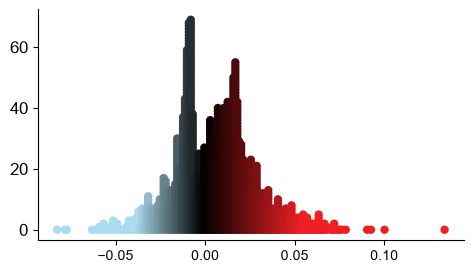

In [12]:
import matplotlib.colors as mcolors

datatype = 'drive'

loading_path = Path('analysis_modules/pca/outputs')
loading_file = Path(f'{datatype}_loadings.csv')
loading_df = pd.read_csv(loading_path / loading_file, index_col=[0,1])

loadings = -loading_df['separation_axis_loading'].to_numpy()
data_range = loadings.max() - loadings.min()
bin_width  = data_range * 0.005

# 3-color gradient
color_min  = '#abdbee'  # Color for negative values
color_zero = '#000000'  # Color for zero/neutral values
color_max  = '#ed2024'  # Color for positive values

cmap = mcolors.LinearSegmentedColormap.from_list(
    'pc_gradient', [color_min, color_zero, color_max]
)
norm = mcolors.TwoSlopeNorm(vcenter=0, vmin=loadings[47], vmax=loadings[-47])

figure_generator = Plotter(output_path = 'figures/pca_loading')
figure_generator.plot_pca_loadings(
    loadings,
    bin_width,
    flip=False,
    color_map = cmap,
    norm=norm,
    edgecolors='none',
    save_as=f'{datatype}_loadings_smooth',
    show_plot=True,
    figsize=(5.5,3),
)

Ignoring 22 missing edges...


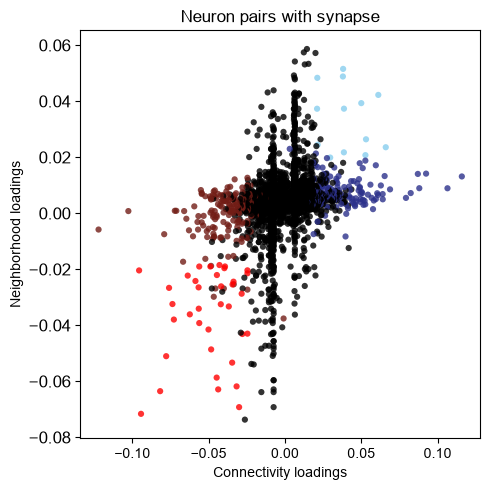

In [35]:
# PC loading vs PC loading
import matplotlib.pyplot as plt
import itertools

c_col = 'connectivity_3_dauer'
n_col = 'neighborhood_3_dauer'

# load 2 pc loading files, plot against each other, json derived from above
loading_path = Path('analysis_modules/pca/outputs')
connectivity_loadings = pd.read_csv(loading_path / 'connectome_loadings.csv', index_col = [0,1])
proximity_loadings = pd.read_csv(loading_path / 'proximity_loadings.csv', index_col = [0,1])

# duplicate neighborhood to match connectivity
inverse_index = proximity_loadings.index.map(lambda x: (x[1], x[0]))
proximity_loadings_invert = proximity_loadings.reindex(index=inverse_index)

proximity_loadings_invert = proximity_loadings.swaplevel('pre', 'post')
proximity_loadings_invert.index.names = ['pre', 'post']
proximity_loadings_invert = proximity_loadings_invert.query("pre != post")
proximity_loadings_total = pd.concat([proximity_loadings, proximity_loadings_invert]).sort_index()
proximity_loadings = proximity_loadings_total.groupby(['pre', 'post']).sum() # cast back to n_el

plot_edges = connectivity_loadings.index.intersection(proximity_loadings.index)
missing_edges = connectivity_loadings.index.difference(proximity_loadings.index)
print(f'Ignoring {len(missing_edges)} missing edges...')

plot_df = pd.concat([
    connectivity_loadings.loc[plot_edges,'separation_axis_loading'],
    proximity_loadings.loc[plot_edges,'separation_axis_loading']
], axis=1)
plot_df.columns = ['connectivity', 'proximity']


classification_path = Path('data/connectomes/metadata/synapse_neighborhood_classification_table.csv')
class_df = pd.read_csv(classification_path, index_col=[0,1])

# base categories
categories = ['increased', 'maintained', 'decreased', 'variable']

# (connectivity_class, neighborhood_class)
joint_classes = list(itertools.product(categories, categories))
colors = {
    ('dauer_increased',   'dauer_increased'):   '#ff0000',
    ('dauer_increased',   'maintained'):  '#721d16',
    ('dauer_increased',   'dauer_decreased'):   '#000000',
    ('dauer_increased',   'variable'):    '#000000',

    ('maintained',  'dauer_increased'):   '#721d16',
    ('maintained',  'maintained'):  '#000000',
    ('maintained',  'dauer_decreased'):   '#2c318b',
    ('maintained',  'variable'):    '#000000',

    ('dauer_decreased',   'dauer_increased'):   '#000000',
    ('dauer_decreased',   'maintained'):  '#2c318b',
    ('dauer_decreased',   'dauer_decreased'):   '#87ceee',
    ('dauer_decreased',   'variable'):    '#000000',

    ('variable',    'dauer_increased'):   '#000000',
    ('variable',    'maintained'):  '#000000',
    ('variable',    'dauer_decreased'):   '#000000',
    ('variable',    'variable'):    '#000000',
}

# Combine plot_df and class_df on the shared (pre, post) multiindex
merged = plot_df.join(class_df[[c_col, n_col]])

# Build joint class column and map to colors
merged['joint_class'] = list(zip(merged[c_col], merged[n_col]))
merged['color'] = merged['joint_class'].map(colors)

# Plot
fig, ax = plt.subplots(figsize=(5, 5))

ax.scatter(
    merged['connectivity'],
    merged['proximity'],
    c=merged['color'],
    s=20,
    alpha=0.8,
    edgecolors='none',
)

ax.set_xlabel('Connectivity loadings')
ax.set_ylabel('Neighborhood loadings')
ax.set_title(f'Neuron pairs with synapse')

present_classes = merged['joint_class'].dropna().unique()
legend_handles = [
    plt.Line2D([0], [0], marker='o', linestyle='',
               markerfacecolor=colors[jc], markeredgecolor='none',
               label=f'{jc[0]} / {jc[1]}')
    for jc in sorted(present_classes)
]

plt.tight_layout()
plt.savefig('figures/pca_loading/con_vs_prox_loadings_3dauer.png',dpi=300,bbox_inches='tight')
plt.show()

# Adj Matrix as Heatmap

Shows dauer increased / dauer decreased on a grid-like heatmap of every neuron pair (pre on top, post on left)

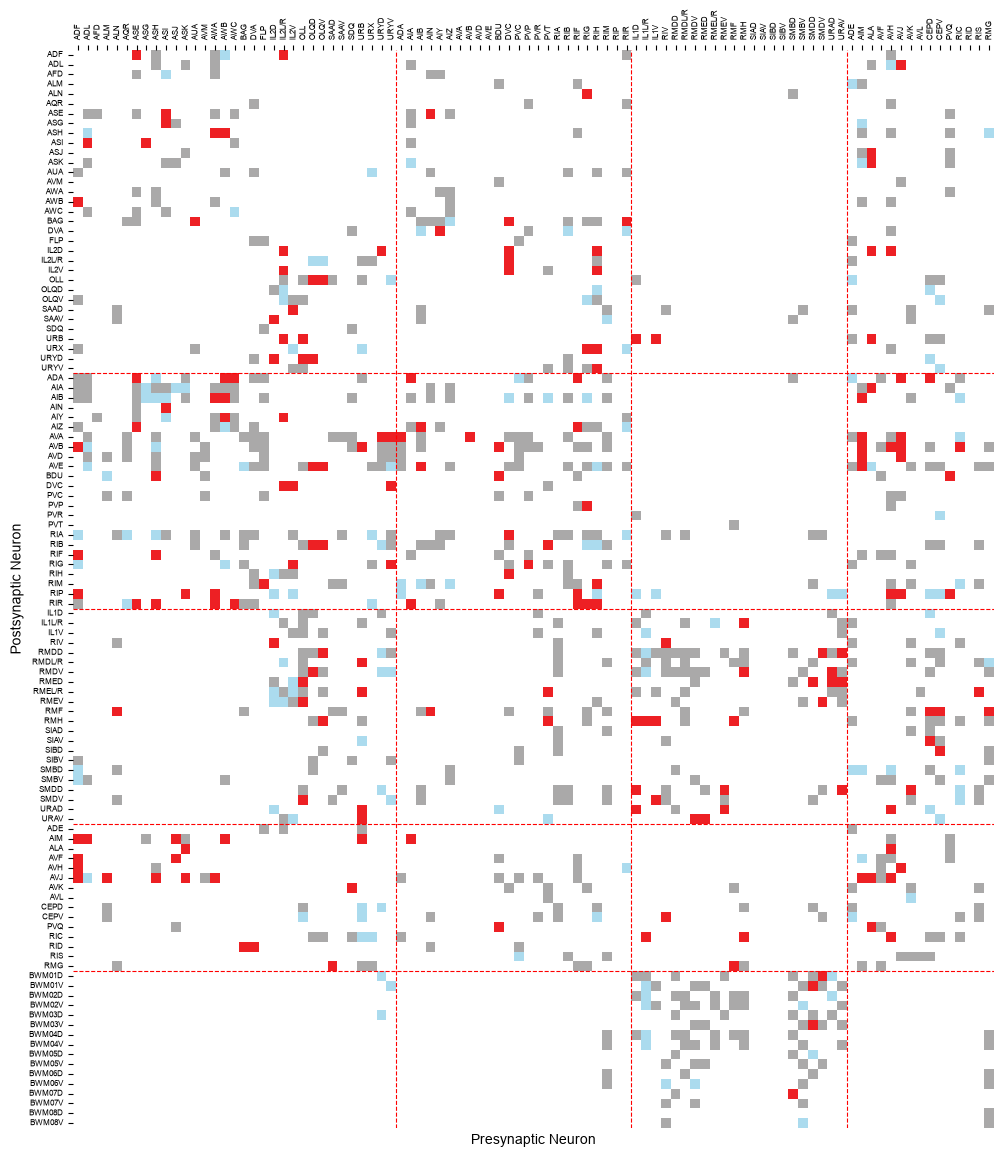

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib as mpl

neuron_order = [
    'ADF','ADL','AFD','ALM','ALN','AQR','ASE','ASG','ASH',
    'ASI','ASJ','ASK','AUA','AVM','AWA','AWB','AWC','BAG',
    'DVA','FLP','IL2D','IL2L/R','IL2V','OLL','OLQD','OLQV',
    'SAAD','SAAV','SDQ','URB','URX','URYD','URYV','ADA',
    'AIA','AIB','AIN','AIY','AIZ','AVA','AVB','AVD','AVE',
    'BDU','DVC','PVC','PVP','PVR','PVT','RIA','RIB','RIF',
    'RIG','RIH','RIM','RIP','RIR','IL1D','IL1L/R','IL1V',
    'RIV','RMDD','RMDL/R','RMDV','RMED','RMEL/R','RMEV',
    'RMF','RMH','SIAD','SIAV','SIBD','SIBV','SMBD','SMBV',
    'SMDD','SMDV','URAD','URAV','ADE','AIM','ALA','AVF',
    'AVH','AVJ','AVK','AVL','CEPD','CEPV','PVQ','RIC','RID',
    'RIS','RMG','BWM01D','BWM01V','BWM02D','BWM02V','BWM03D',
    'BWM03V','BWM04D','BWM04V','BWM05D','BWM05V','BWM06D',
    'BWM06V','BWM07D','BWM07V','BWM08D','BWM08V'
  ]

# Create the adjacency matrix
neuron_map = {neuron: order for order, neuron in enumerate(neuron_order)}
n = len(neuron_order)
matrix = pd.DataFrame(
    index=neuron_order,
    columns=neuron_order[:-16],
    data = np.nan)

# load classification data
classification_path = Path('data/connectomes/metadata/synapse_neighborhood_classification_table.csv')
class_data = pd.read_csv(classification_path, index_col=[0,1])

for idx, row in class_data['connectivity_3_dauer'].items():
    if row == 'maintained':
        matrix.loc[idx[1], idx[0]] = 0
    elif row == 'dauer_increased':
        matrix.loc[idx[1], idx[0]] = 1
    elif row == 'dauer_decreased':
        matrix.loc[idx[1], idx[0]] = -1

cmap = mpl.colors.LinearSegmentedColormap.from_list("n",[
    '#abdbee','#aaaaaa','#ed2024'])

# Create the heatmap
plt.figure(figsize=(14, 14))
g = sns.heatmap(
    matrix,
    xticklabels=neuron_order[:-16],
    yticklabels=neuron_order,
    cbar = False,
    # cbar_kws={"shrink": 0.5},
    cmap = cmap,
    vmin = -1,
    vmax = 1,
    square = True)

g.xaxis.tick_top()
plt.xticks(rotation=90, fontsize=6)
plt.yticks(fontsize=6)

# Customize gridline locations
x_coords = [33, 57, 79]
y_coords = [33, 57, 79, 94]

for xc in x_coords:
  plt.axvline(x=xc, color='red', linestyle='--', linewidth=0.8)
for yc in y_coords:
  plt.axhline(y=yc, color='red', linestyle='--', linewidth=0.8)

plt.xlabel("Presynaptic Neuron")
plt.ylabel("Postsynaptic Neuron")

plt.savefig("figures/heatmap.pdf", dpi=300, bbox_inches='tight')
plt.show()

# Cosine Similarity Matrix

Cosine matrix is calculated in `analysis_modules/cosine_similarity`. The plot will output to `figures/cosine_sim`

Created directory: figures/cosine_sim
Saved figure to figures/cosine_sim\cosine_similarity_connectome.png and figures/cosine_sim\cosine_similarity_connectome.pdf


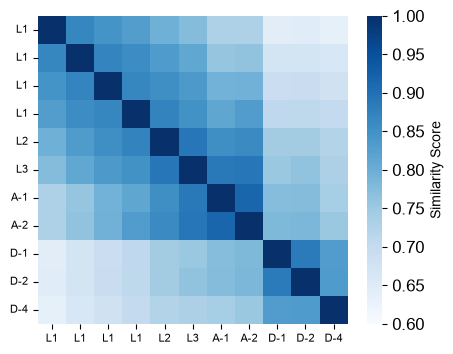

In [24]:
import numpy as np
from pathlib import Path
from plotting.plotter import Plotter
import json

datatype = 'connectome' # connectome, proximity, drive

matrix_path = Path('analysis_modules/cosine_similarity/outputs')
matrix_file = Path(f'{datatype}_similarity_matrix.json')

with open(matrix_path / matrix_file) as f:
    data = json.load(f)

similarity_matrix = np.array(data['matrix'])
labels = data['labels']

figure_generator = Plotter(output_path = 'figures/cosine_sim')
figure_generator.plot_cosine_similarity(
    similarity_matrix, labels=labels,
    annot=False, cmap='Blues', vmax=1, vmin=0.6,
    save_as = f'cosine_similarity_{datatype}'
)

# Visualizing proximity points and meshes

Mesh and points cloud files will be temporarily hosted on a google drive until moved to a more permanent location.

For now, the link to mesh:

https://drive.google.com/drive/folders/1uPIfb2O6muAtRv1XIV3ozGMnuKEnTWYJ

You can download a folder into your current directory using `!gdown --folder folder-id` where folder-id is the part of the url after /folders/

In [ ]:
import os

# just to ensure points folder is put inside paper code folder
if os.getcwd() != '/content/dauer_paper':
    os.chdir('/content/dauer_paper')

# Download proximity points from my public drive
# !gdown --folder 1ydZ8BqXoBXcHYTHTXt44Tt4krAGWZawB

from pathlib import Path
from analysis_modules.src.data_manager import DataManager

dm = DataManager(
    data_path='data',
    include_postemb=True,
    include_muscle=True,
    npair_result=True
)

dm.specify_proximity_points_dir(
    Path('proximity_point_data'), ext='.csv'
)

In [ ]:
datasets = ['dauer-1']

point_data = dm.get_proximity_points(
    datasets = datasets
)

Set proximity points directory as proximity_point_data.


{'dauer-1':        neuron             x             y             z ADA ADE ADF ADL AFD  \
 0        URYV   6339.065723  27601.310125  43812.234449   0   0   0   0   0   
 1        URYV   3533.118552  27840.105478  42549.578474   0   0  12   0   2   
 2        URYV   2668.971251   29205.38262  38069.817056   0   0   0   0   0   
 3        URYV   5180.112601  26997.704097  43919.180324   0   0   0   0   0   
 4        URYV   6410.013644  30818.732547  39071.395646   0   0   0   0   0   
 ...       ...           ...           ...           ...  ..  ..  ..  ..  ..   
 211995    RIC   8523.700186  35707.165567  51691.364673   0   0   0   0   0   
 211996    RIC  15066.368576  24900.271095   41812.19768   0   0   0   0   0   
 211997    RIC   6587.204339  20850.913732  38301.061586   0   0   0   0   0   
 211998    RIC   8356.858489  32967.877469  53347.608092   0   0   0   0   0   
 211999    RIC   4863.063909  27566.652925  41490.102739   0   0   0   0   0   
 
        AIA  ... SMBD SMBV 

**Attaching connectors or visualizing density of local connectors**

In [ ]:
import os
import matplotlib.colors as mcolors
import pandas as pd
import numpy as np

# skip previous step
points_dataset = 'dataset6'
dataset = 'L3'
camera_view = 'default'
neuron = 'RIC'
datatype = 'output'
partner = 'AVA'
symmetry = 'L' # 'L', 'R', 'paired', 'none
custom_cmap = [(0, '#eeeeee'), (0.5, '#cecece'), (1, '#fe0404')]
# pre_drive = pd.read_csv(f'{dataset}_local_pre_drive.csv',index_col=0)
# post_drive = pd.read_csv(f'{dataset}_local_post_drive.csv',index_col=0)

pre_drive = pd.read_csv(f'{dataset}_pre_local_cons.csv',index_col=0)
post_drive = pd.read_csv(f'{dataset}_post_local_cons.csv',index_col=0)

if datatype == 'input':
    # custom_cmap = [(0, '#eeeeee'), (0.5, '#cecece'), (1, '#0404fe')]
    filt = pre_drive['neuron'] == neuron
    input_df = pre_drive[filt]
elif datatype == 'output':
    # custom_cmap = [(0, '#eeeeee'), (0.5, '#cecece'), (1, '#fe0404')]
    filt = post_drive['neuron'] == neuron
    input_df = post_drive[filt]

assert symmetry in ['L','R','paired', 'none']
if symmetry == 'L':
    input_df = input_df.iloc[:1000,:]
elif symmetry == 'R':
    input_df = input_df.iloc[1000:,:]
else:
    pass

mean_points = assign_values_by_radius(
    df_original = input_df,
    df_new = input_df,
    metric = partner,
    radius = 500,
    method = 'mean'
)

filt_contact = points[points_dataset].loc[filt,partner]>0

plot_df = mean_points.copy()
plot_df.loc[filt_contact,'value'] = plot_df.loc[filt_contact,'value'] + 4

# plot_df.to_csv(f'outputs/drive_{dataset}_{neuron+symmetry}+{partner}+{datatype}.csv')

camera = dict(
    center={'x': 0, 'y': 0, 'z': 0},
    eye={'x': -1, 'y': -1, 'z': 1.8},
    up={'x': 0, 'y': -1, 'z': 0}
)

plot_score_neuron(
    plot_data = plot_df,
    camera_view = camera,
    metric='value',
    range_color = [0,8],
    # output_path=f'outputs/drive_{dataset}_{neuron+symmetry}+{partner}+{datatype}.png',
    cmap = custom_cmap,
)

# proximity classification

In [ ]:
from analysis_modules.src.utils import exclude_postemb_edgetable
from analysis_modules.src.data_manager import DataManager

nondauers = ['L2','L3','adult-2']
dauers = ['dauer-1','dauer-2','dauer-3']

dm = DataManager(
    data_path='data',
    include_postemb=True,
    include_muscle=True,
    npair_result=True
)

proximity = dm.get_data_edgetable('proximity')[nondauers+dauers]

exclude_list = ['PVW','PLN','HSN']
proximity = exclude_postemb_edgetable(proximity, nondauers+dauers)

proximity[proximity<10] = 0
log_proximity = np.log(proximity[proximity>0])
G = log_proximity.fillna(0).copy()

G['classification'] = 'variable'
G.loc[(G[dauers].min(axis=1)>0)|(G[nondauers].min(axis=1)>0),'classification'] = 'maintained'

# all dauers > all nondauers and vice versa
increased_filt_1 = G[dauers].min(axis=1)>G[nondauers].max(axis=1)
decreased_filt_1 = G[dauers].max(axis=1)<G[nondauers].min(axis=1)

G['mean_nondauer'] = 0
G.loc[:,'mean_nondauer'] = G.loc[:,nondauers].mean(axis=1)
G['mean_dauer'] = G.loc[:,dauers].mean(axis=1)

# fold change threshold
increased_filt_2 = (G['mean_dauer'] - G['mean_nondauer'])>2.25
decreased_filt_2 = (G['mean_nondauer'] - G['mean_dauer'])>2.25

G.loc[increased_filt_1 & increased_filt_2,'classification'] = 'dauer_increased'
G.loc[decreased_filt_1 & decreased_filt_2,'classification'] = 'dauer_decreased'

# G.to_csv('proximity_classification.csv')

# Connection-to-proximity Significance

Simulated Statistics vs Real Data:
--------------------------------------------------------------------------------
| Combination | Mean | Std Dev | Real Count | Difference |
--------------------------------------------------------------------------------
| S-C-         | 593.45 |   14.93 |        627 |      33.55 |
| S+C-         | 318.92 |   14.03 |        288 |     -30.92 |
| S-C+         |  34.36 |    5.58 |          3 |     -31.36 |
| S+C+         |  18.28 |    4.30 |         50 |      31.72 |
--------------------------------------------------------------------------------


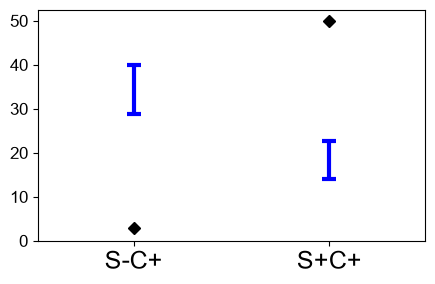

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# contact_proportions = {
#     'C-': 925,
#     'C+': 54
# }
# synapse_proportions = {
#     'S-': 590,
#     'S+': 389
# }
# total_observations = 979
# real_data = {
#     'S-C-': 581,
#     'S+C-': 344,
#     'S-C+': 9,
#     'S+C+': 45
# }

# Define the proportions
contact_proportions = {
    'C-': 915,
    'C+': 53
}
synapse_proportions = {
    'S-': 630,
    'S+': 338
}
total_observations = 965

# Real data
real_data = {
    'S-C-': 627,
    'S+C-': 288,
    'S-C+': 3,
    'S+C+': 50
}

np.random.seed(47)

def generate_random_sample(proportions, size):
    categories = list(proportions.keys())
    values = list(proportions.values())
    total = sum(values)

    # Calculate probabilities
    probabilities = [val / total for val in values]

    # Generate random samples
    samples = np.random.choice(categories, size=size, p=probabilities)
    return samples

# Function to count combinations
def count_combinations(synapses, contacts):
    combinations = {}
    for i in range(total_observations):
        combo = f"{synapses[i]}{contacts[i]}"
        combinations[combo] = combinations.get(combo, 0) + 1
    return combinations

# Define all possible combinations
all_combinations = [
    'S-C-', 'S+C-', 'S-C+', 'S+C+'
]

# Perform parametric bootstrapping
num_repeats = 1000
results = []

for i in range(num_repeats):
    contacts = generate_random_sample(contact_proportions, total_observations)
    synapses = generate_random_sample(synapse_proportions, total_observations)
    combinations = count_combinations(synapses, contacts)
    results.append(combinations)

# Calculate mean and standard deviation for each combination
stats = {}

for combo in all_combinations:
    values = [result.get(combo, 0) for result in results]
    # Calculate mean
    mean = np.mean(values)
    # Calculate standard deviation
    std = np.std(values)
    stats[combo] = {'mean': mean, 'std': std}

# Print results in a table format
print("Simulated Statistics vs Real Data:")
print("-" * 80)
print("| Combination | Mean | Std Dev | Real Count | Difference |")
print("-" * 80)

for combo in all_combinations:
    mean = stats[combo]['mean']
    std = stats[combo]['std']
    real = real_data.get(combo, 0)
    diff = real - mean

    print(f"| {combo:<12} | {mean:6.2f} | {std:7.2f} | {real:10} | {diff:10.2f} |")
print("-" * 80)

# Format data for visualization
plot_data = []
for combo in all_combinations:
    plot_data.append({
        'combination': combo,
        'mean': stats[combo]['mean'],
        'std': stats[combo]['std'],
        'real': real_data.get(combo, 0),
        'lower_bound': stats[combo]['mean'] - stats[combo]['std'],
        'upper_bound': stats[combo]['mean'] + stats[combo]['std']
    })

plot_data = pd.concat([pd.DataFrame(stats).T, pd.Series(real_data, name='realdata')], axis=1)
plot_data = plot_data.iloc[2:]
# plot_data = plot_data.iloc[:2]

plt.figure(figsize=(5, 3))
plt.bar(plot_data.index, plot_data['mean'], yerr=plot_data['std'],
        align='center', alpha=0, error_kw=dict(ecolor='blue', lw=3, capsize=5, capthick=3))
plt.plot(plot_data.index, plot_data['realdata'], marker="D", linestyle="", color="black")
plt.xticks(fontsize=18)
# plt.ylim((200,700))
# plt.yticks(np.arange(200,700,250), fontsize=18)
# plt.title('Simulation vs Real data (contactome/connectome)')
plt.savefig('figures/contactome_connectome_sim.png', dpi=300, bbox_inches='tight')
plt.show()

# Drive scatterplot

In [39]:
from analysis_modules.src.data_manager import DataManager
from analysis_modules.src.utils import exclude_postemb_edgetable

dm = DataManager(
    data_path = 'data',
    include_postemb=True,
    include_muscle=True,
    npair_result=True
)

datasets = [
    'L1-1','L1-2','L1-3','L1-4',
    'L2','L3','adult-2',
    'dauer-1','dauer-2'
]

G = dm.get_drive_edgetable(consistent=False)
G = exclude_postemb_edgetable(G, datasets)
G = G[G.sum(axis=1) > 0]

G['dauer_mean'] = G[['dauer-1','dauer-2']].mean(axis=1)
G['nondauer_mean'] = G[['L1-1','L1-2','L1-3','L1-4','L2','L3','adult-2']].mean(axis=1)

dauer_only = G[G['nondauer_mean'].isna()]
nondauer_only = G[G['dauer_mean'].isna()]

plot_data = G[~G.index.isin(dauer_only.index.union(nondauer_only.index))]

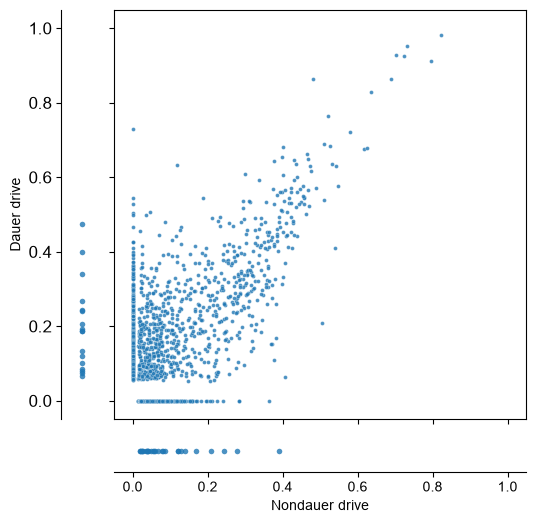

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

dauer_only = G[G['nondauer_mean'].isna()]
nondauer_only = G[G['dauer_mean'].isna()]
plot_data = G[~G.index.isin(dauer_only.index.union(nondauer_only.index))]

fig = plt.figure(figsize=(6, 6))

# 2x2 grid plot
gs = fig.add_gridspec(
    nrows=2,
    ncols=2,
    width_ratios=(0.5, 5),
    height_ratios=(5, 0.5),
    wspace=0.05, # Minimize whitespace between plots
    hspace=0.05
)

# Define subplots and link axes
ax_main = fig.add_subplot(gs[0, 1])
ax_left = fig.add_subplot(gs[0, 0], sharey=ax_main)
ax_bottom = fig.add_subplot(gs[1, 1], sharex=ax_main)

# Main Scatterplot
sns.scatterplot(
    data=plot_data,
    x='nondauer_mean',
    y='dauer_mean',
    ax=ax_main,
    # color='purple',
    s=8,
    alpha=0.8
)

# Left Vertical Swarmplot
sns.stripplot(
    y=dauer_only['dauer_mean'],
    ax=ax_left,
    # color='blue',
    size=4,
    jitter=0,
    alpha=0.8
)

# Bottom Horizontal Swarmplot
sns.stripplot(
    x=nondauer_only['nondauer_mean'],
    ax=ax_bottom,
    # color='red',
    size=4,
    jitter=0,
    alpha=0.8
)

ax_main.set_xlim(-0.05, 1.05)
ax_main.set_ylim(-0.05, 1.05)

# shift labels to the outer edges
ax_main.set_xlabel("")
ax_main.set_ylabel("")
ax_main.tick_params(labelbottom=False, labelleft=False)

# Format Left Plot
ax_left.set_ylabel("Dauer drive")
ax_left.set_xlabel("")
ax_left.set_xticks([]) # Remove internal x-ticks
ax_left.spines[['top', 'right', 'bottom']].set_visible(False)

# Format Bottom Plot
ax_bottom.set_xlabel("Nondauer drive")
ax_bottom.set_ylabel("")
ax_bottom.set_yticks([]) # Remove internal y-ticks
ax_bottom.spines[['top', 'right', 'left']].set_visible(False)

plt.savefig('figures/double_drive_plot.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Neurons with most changed drive

In [49]:
import json
import numpy as np
import pandas as pd

dauer_label = {
    'L1-1': 'nondauer',
    'L1-2': 'nondauer',
    'L1-3': 'nondauer',
    'L1-4': 'nondauer',
    'L2': 'nondauer',
    'L3': 'nondauer',
    'adult-1': 'nondauer',
    'adult-2': 'nondauer',
    'dauer-1': 'dauer',
    'dauer-2': 'dauer',
    'dauer-3': 'dauer',
    'dauer-daf2': 'dauer'
}

with open('analysis_modules/pca/outputs/pca_drive.json', 'r') as f:
    pca_loadings = json.load(f)

pca_scores = np.array(pca_loadings['features'])
labels = np.array([dauer_label[label] for label in pca_loadings['labels']])
edge_labels = np.array([[edge.split('-')[0],edge.split('-')[1]] for edge in pca_loadings['edge_labels']])
edge_pre = edge_labels[:,0]
edge_post = edge_labels[:,1]
loadings = np.array(pca_loadings['loadings'])

# Find Cluster Centroids in 2D PCA space
coords_nondauer = pca_scores[labels == 'nondauer']
coords_dauer = pca_scores[labels == 'dauer']
centroid_nondauer = np.mean(coords_nondauer, axis=0)
centroid_dauer = np.mean(coords_dauer, axis=0)

# Calculate the Normalized Direction Vector (Axis of Separation)
direction_vector = centroid_nondauer - centroid_dauer
norm_vector = np.linalg.norm(direction_vector)
unit_vector = direction_vector / norm_vector

# Project original loadings onto the new axis
# Matrix multiplication: (k, 2) @ (2,) -> (k,)
new_axis_loadings = np.dot(loadings, unit_vector)

results_df = pd.DataFrame({
    'pre': edge_pre,
    'post': edge_post,
    'PC1_loading': loadings[:, 0],
    'PC2_loading': loadings[:, 1],
    'separation_axis_loading': new_axis_loadings
})
results_df.set_index(['pre','post'], inplace=True)
results_df = results_df.sort_values(by='separation_axis_loading', ascending=False)

In [50]:
import pandas as pd

# get pca loadings
pca_loadings = abs(results_df['separation_axis_loading'])

# Sum
outgoing = pca_loadings.groupby(level=0).sum()
incoming = pca_loadings.groupby(level=1).sum()
outgoing_count = pca_loadings.groupby(level=0).count()
incoming_count = pca_loadings.groupby(level=1).count()

# Add them together to get the total weight per node
total_weights = outgoing.add(incoming, fill_value=0)
total_count = outgoing_count.add(incoming_count, fill_value=0)

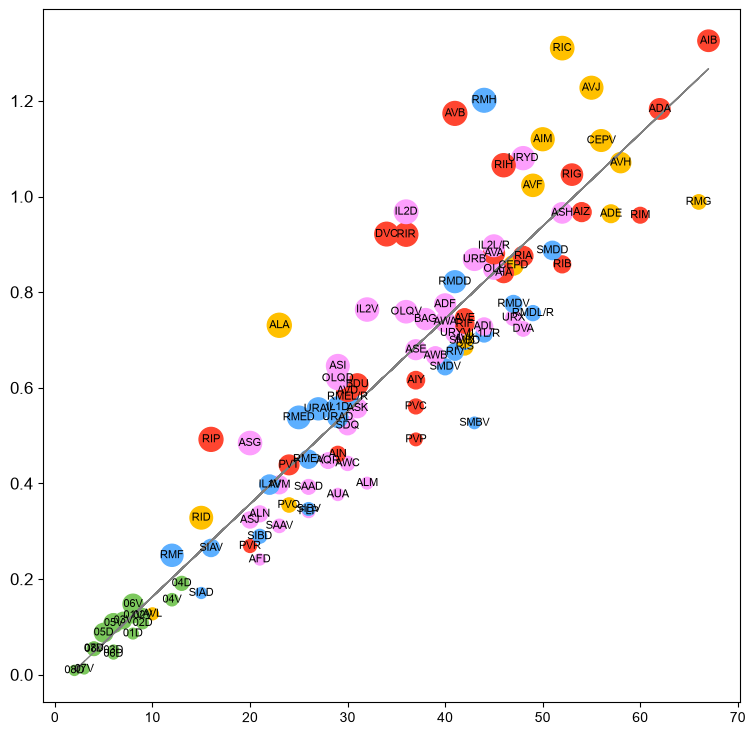

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
# from adjustText import adjust_text
from analysis_modules.src.neuron_info import ntype
plt.rcParams['svg.fonttype'] = 'none'

color_dict = {
    'sensory': '#fd9ffd',
    'inter': '#ff4530',
    'motor': '#5cafff',
    'modulatory': '#ffc000',
    'muscle': '#7cc85d'
}

ntypes = pd.Series({i:ntype(i) for i in total_weights.index},name='type')
plot_df = pd.concat([
    total_weights.rename('loadings'),
    total_count.rename('count'),
    ntypes],axis=1)

plot_df = plot_df[~plot_df['count'].isna()]
labels_sorted = (plot_df['loadings']/plot_df['count']).sort_values().index
plot_df = plot_df.loc[labels_sorted]

colors = [color_dict[t] for t in plot_df['type']]

x = plot_df['count']
y = plot_df['loadings']
slope, intercept = np.polyfit(x, y, 1)
plt.figure(figsize=(9,9))

plt.plot(x, slope * x + intercept, color='grey', linewidth=1)
plt.scatter(
    x,
    y,
    c = colors,
    s=np.arange(50,300,(300-50)/len(x)),
)
plot_df.index = plot_df.index.str.replace(r'BWM', '', regex=True)
texts = [plt.text(row['count'], row['loadings'], i, fontsize=8, ha='center', va='center') for i, row in plot_df.iterrows()]
# adjust_text(texts)


# plt.gca().yaxis.set_inverted(True)
# plt.gca().xaxis.set_label_position('top')
# plt.gca().xaxis.tick_top()
# plt.yticks(np.arange(0, 20, 5))
plt.savefig('figures/hub_plot.svg',dpi=300,bbox_inches='tight')

# Motif analysis

In [ ]:
# unsigned graphs - i.e. no color labels

import networkx as nx
import itertools
from collections import Counter
import numpy as np
import json

np.random.seed(47)

def build_graph(edge_list):
    """Constructs a directed graph from a list of tuple edges."""
    G = nx.DiGraph()
    G.add_edges_from(edge_list)
    return G

def count_k_node_motifs(G, k):
    """
    Finds and counts all k-node subgraphs.
    Uses Weisfeiler-Lehman graph hashing to group isomorphic subgraphs.
    Note: Scales at O(N^k). For very large graphs, edge-sampling is required.
    """
    motif_counts = Counter()
    motif_representatives = {} # Store one example graph per hash

    for nodes in itertools.combinations(G.nodes(), k):
        subgraph = G.subgraph(nodes)

        # if nx.is_weakly_connected(subgraph):
        g_hash = nx.weisfeiler_lehman_graph_hash(subgraph)
        motif_counts[g_hash] += 1

        if g_hash not in motif_representatives:
            motif_representatives[g_hash] = nx.DiGraph(subgraph)

    return motif_counts, motif_representatives

def generate_directed_configuration_model(G):
    """
    Generates a randomized network preserving the exact in-degree
    and out-degree of every node in the original graph.
    """
    in_seq = [d for n, d in G.in_degree()]
    out_seq = [d for n, d in G.out_degree()]

    # Generate the configuration model (creates a MultiDiGraph)
    random_G = nx.directed_configuration_model(in_seq, out_seq, seed = np.random)

    # The configuration model can create parallel edges and self-loops.
    # We convert it back to a simple DiGraph to match our standard network constraints.
    random_G = nx.DiGraph(random_G)
    # random_G.remove_edges_from(nx.selfloop_edges(random_G))

    return random_G

def analyze_motifs(edge_list, k=3, num_random=100):
    """
    Conducts the full motif analysis by comparing the actual network
    against a baseline of randomized configuration models.

    Really only recommend for k=4 at most
    """
    G = build_graph(edge_list)
    print(f"Analyzing Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

    # Count motifs in the original graph
    if k == 3:
        actual_motifs = nx.triadic_census(G)
    else:
        # hash-based counter for k>3
        actual_motifs, actual_repr = count_k_node_motifs(G, k)

    # Build distributions for the null model
    random_motif_distributions = {motif: [] for motif in actual_motifs.keys()}

    for i in range(num_random):
        random_G = generate_directed_configuration_model(G)

        if k == 3:
            rand_motifs = nx.triadic_census(random_G)
        else:
            rand_motifs, _ = count_k_node_motifs(random_G, k)

        # Record the occurrences of each motif in this random iteration
        for motif in actual_motifs.keys():
            random_motif_distributions[motif].append(rand_motifs.get(motif, 0))

    # Calculate Z-Scores for statistical significance
    results = {}
    for motif, actual_count in actual_motifs.items():
        rand_counts = random_motif_distributions[motif]
        mean_rand = np.mean(rand_counts)
        std_rand = np.std(rand_counts)

        # Z-score measures how many standard deviations the actual count is from the random mean
        z_score = (actual_count - mean_rand) / std_rand if std_rand > 0 else 0.0

        results[motif] = {
            'Actual': actual_count,
            'Random_Mean': round(mean_rand, 2),
            'Z_Score': round(z_score, 3)
        }
        if k == 4:
            results[motif]['Representative'] = actual_repr[motif]

    return results

In [ ]:
# signed graphs i.e. dauer_increased, decreased, blue, red, etc.
import networkx as nx
import pandas as pd
import itertools
from collections import Counter
import numpy as np
from tqdm import tqdm

np.random.seed(47)
def build_signed_graph(series: pd.Series) -> nx.DiGraph:
    """
    Constructs a directed graph with edge signs from a Pandas Series.
    Expects a multi-index [(source, target)] and values as weights.
    """
    G = nx.DiGraph()
    for (u, v), weight in series.items():
        sign = 1 if weight >= 0 else -1
        G.add_edge(u, v, sign=sign)
    return G

def count_signed_k_node_motifs(G, k):
    """
    Finds and counts all k-node signed subgraphs.
    Uses WL graph hashing with explicit in/out degree initialization
    to preserve edge direction and sign.
    """
    motif_counts = Counter()
    motif_representatives = {}

    for nodes in itertools.combinations(G.nodes(), k):
        subgraph = G.subgraph(nodes).copy()

        # Match degree
        for n in subgraph.nodes():
            subgraph.nodes[n]['in_out_deg'] = f"{subgraph.in_degree(n)}_{subgraph.out_degree(n)}"

        # sign and label required for unique hash
        g_hash = nx.weisfeiler_lehman_graph_hash(
            subgraph,
            edge_attr='sign',
            node_attr='in_out_deg'
        )

        motif_counts[g_hash] += 1

        if g_hash not in motif_representatives:
            motif_representatives[g_hash] = subgraph

    return motif_counts, motif_representatives

def generate_signed_configuration_model(G):
    """
    Generates a randomized network preserving the total in/out-degree sequence,
    and assigns signs matching the global sign distribution of the original graph.
    """
    in_seq = [d for n, d in G.in_degree()]
    out_seq = [d for n, d in G.out_degree()]

    # Generate standard topology
    random_G = nx.directed_configuration_model(in_seq, out_seq, seed = np.random)
    random_G = nx.DiGraph(random_G)
    # random_G.remove_edges_from(nx.selfloop_edges(random_G)) # retain self-connections

    # Extract original signs and shuffle them
    original_signs = [d['sign'] for u, v, d in G.edges(data=True)]
    num_random_edges = random_G.number_of_edges()

    # Configuration model drops self-loops/multi-edges, so E_random <= E_actual.
    # sample without replacement if possible, otherwise with replacement.
    replace = num_random_edges > len(original_signs)
    sampled_signs = np.random.choice(original_signs, size=num_random_edges, replace=replace)

    # Re-apply the shuffled signs to the random graph edges
    for (u, v), sign in zip(random_G.edges(), sampled_signs):
        random_G[u][v]['sign'] = sign

    return random_G

def analyze_signed_motifs(series: pd.Series, k=3, num_random=100):
    """q
    Conducts the full signed motif analysis.
    """
    G = build_signed_graph(series)
    print(f"Analyzing Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

    # Count actual signed motifs
    actual_motifs, actual_repr = count_signed_k_node_motifs(G, k)

    # Initialize distributions for the null model
    random_motif_distributions = {motif: [] for motif in actual_motifs.keys()}

    for i in tqdm(range(num_random), desc="Calculating..."):
        random_G = generate_signed_configuration_model(G)
        rand_motifs, _ = count_signed_k_node_motifs(random_G, k)

        for motif in actual_motifs.keys():
            random_motif_distributions[motif].append(rand_motifs.get(motif, 0))

    # Calculate significance
    results = {}
    for motif, actual_count in actual_motifs.items():
        rand_counts = random_motif_distributions[motif]
        mean_rand = np.mean(rand_counts)
        std_rand = np.std(rand_counts)

        z_score = (actual_count - mean_rand) / std_rand if std_rand > 0 else 0.0

        results[motif] = {
            'Actual': actual_count,
            'Random_Mean': round(mean_rand, 2),
            'Z_Score': round(z_score, 3),
            'Representative_Graph': actual_repr[motif] # Graph object for plot
        }

    return results

In [ ]:
# load motif counts from json
import matplotlib.pyplot as plt
import numpy as np
import json

with open('signed_results_3.json', 'r') as f:
    data = json.load(f)

# Extract motifs and Z-scores
motifs = list(data.keys())

if len(motifs[0]) > 8:
    motifs_shorthand = [text[:8] for text in motifs]
else:
    motifs_shorthand = motifs
z_scores = [data[m]["Z_Score"] for m in motifs]

# Define colors based on significance threshold
colors = []
for z in z_scores:
    if z >= 3:
        colors.append('#d62728')  # Red for significantly over-represented
    elif z <= -3:
        colors.append('#1f77b4')  # Blue for significantly under-represented
    else:
        colors.append('#cccccc')  # Grey for non-significant

# Setup the figure for publication quality
plt.rcParams.update({'font.size': 12, 'font.family': 'sans-serif'})
fig, ax = plt.subplots(figsize=(12, 6))

# Create bar chart
bars = ax.bar(motifs_shorthand, z_scores, color=colors, edgecolor='black', linewidth=0.5)

# Add significance threshold lines
ax.axhline(0, color='black', linewidth=1) # Baseline

# Labels and title
ax.set_ylabel('Z-Score', fontweight='bold')
ax.set_xlabel('3-Node Motif ID', fontweight='bold')
ax.set_title('Network Motif Significance Profile', pad=15)

# Formatting
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xticks(rotation=45, ha='right')

# Adjust layout and show/save
plt.tight_layout()
plt.savefig('figures/motif_significance_profile_signed3.pdf', dpi=300, bbox_inches='tight')
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'signed_results_3.json'

# Manual input stacked bar

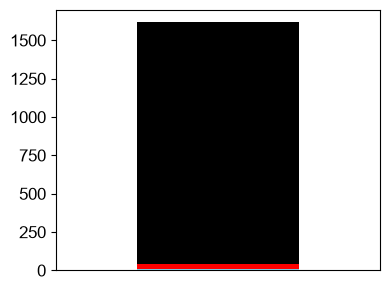

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

index = [
    'maintained',
    'dauer_increased',
    'dauer_decreased',
    'variable',
]
values = [11,33,1573,0]

df_plot = pd.Series(values, index=index, name='count').to_frame().T

colors = ['skyblue', 'red', 'black','grey']

# Plotting
ax = df_plot.plot(kind='bar', color=colors, stacked=True, figsize=(4, 3), legend=False)
plt.xticks(([]),rotation=0)
plt.xlabel('')
plt.tight_layout()
plt.savefig('figures/stacked_bar_chart.svg', dpi=300, bbox_inches='tight')
plt.show()

# Linkage plot (dendrogram)

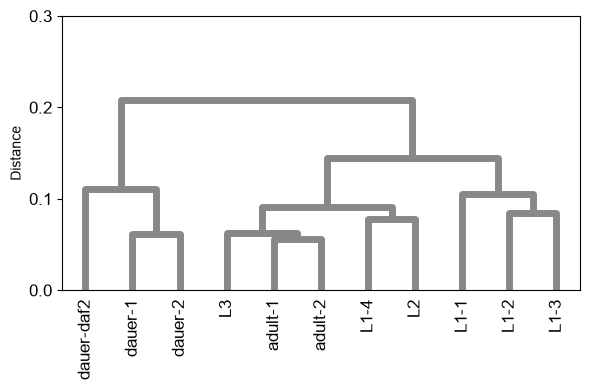

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage, set_link_color_palette

def plot_graph_clustering(graph_array, graph_labels=None, method='ward', metric='euclidean'):
    """
    Generates a hierarchical clustering dendrogram for a set of graphs.

    Parameters:
    - graph_array (np.array): A 2D array of shape (n_graphs, n_edges).
    - graph_labels (list): A list of string labels for each graph (optional).
    - method (str): The linkage algorithm to use (e.g., 'ward', 'average', 'complete').
    - metric (str): The distance metric to use (e.g., 'euclidean', 'cosine', 'cityblock').
    """
    Z = linkage(graph_array, method=method, metric=metric)

    set_link_color_palette(['#888888'])

    plt.figure(figsize=(6, 4))
    # plt.title('Hierarchical Clustering Dendrogram of Weighted Graphs')
    # plt.xlabel('Graph Identifier')
    plt.ylabel('Distance')

    with plt.rc_context({'lines.linewidth': 5}):
        dendrogram(
            Z,
            labels=graph_labels,
            leaf_rotation=90.,  # Rotates the x-axis labels for readability
            leaf_font_size=12., # Font size for the x-axis labels
            show_contracted=True,
            above_threshold_color='#888888'
    )

    plt.yticks(np.arange(0,0.4,0.1))

    plt.tight_layout()
    plt.savefig('figures/dendrogram.png',dpi=300)
    plt.show()


G = dm.get_data_edgetable('connectome')
labels = dm.get_data_edgetable('connectome').columns

plot_graph_clustering(
    np.array(G).T,
    graph_labels=labels,
    method='average',
    metric='cosine')